[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ushaloy/SAVE-LEWS/blob/main/notebooks/00_reproduce_all_figures_and_tables.ipynb)

# SAVE-LEWS — reproduce every figure and table of the manuscript (fast mode)

*Matching physics to observations: physics-guided soil-moisture prediction from low-cost IoT sensors for landslide early warning. The SAVE framework (Screening–Attribution–Validation for Early warning), tested on a LoRaWAN network in southern Thailand and USGS hillslope stations in Puerto Rico.*

This notebook regenerates **Figs. 1–11 and S1–S9** and the **numbers behind Tables 2 and 5–9 and S1–S9** of the revised manuscript from the raw sensor data and the stored model outputs in this repository. It trains nothing and runs in about 2 minutes on a free Colab CPU.

| Data | Source |
|---|---|
| Thailand, Dev108 and Dev107 (RK520 FDR probe at 30 cm, tipping-bucket rain, LoRaWAN) | installed and operated by the authors — `data/thailand/` |
| Puerto Rico, Utuado and Toro Negro hillslope stations (15-min, five soil-moisture depths, piezometers, rain) and laboratory soil tests | Smith, J.B., Thomas, M.A., Ashland, F., Michel, A., Mirus, B.B., Wayllace, A. (2020) Hillslope hydrologic monitoring data following Hurricane Maria in 2017, Puerto Rico, July 2018 to June 2020. U.S. Geological Survey data release, https://doi.org/10.5066/P9548YK2 — `data/puerto_rico/` |

To re-run the models themselves, use notebooks 01–07 (see the README for run times).

In [1]:
import os, sys, subprocess
REPO_URL = 'https://github.com/Ushaloy/SAVE-LEWS'   # <-- set this to your GitHub repository before running in Colab
def _repo_root():
    here = os.getcwd()
    for c in [here, os.path.dirname(here), '/content/SAVE-LEWS', os.path.join(here, 'SAVE-LEWS')]:
        if os.path.exists(os.path.join(c, 'thailand', 'data_pipeline.py')):
            return c
    dst = '/content/SAVE-LEWS' if 'google.colab' in sys.modules else os.path.join(here, 'SAVE-LEWS')
    subprocess.run(['git', 'clone', '--depth', '1', REPO_URL, dst], check=True)
    return dst
ROOT = _repo_root(); os.chdir(os.path.join(ROOT, '.'))
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', os.path.join(ROOT, 'requirements.txt')], check=True)
print('repository:', ROOT)


repository: /content/SAVE-LEWS


## 1. Figures

**Fig01**

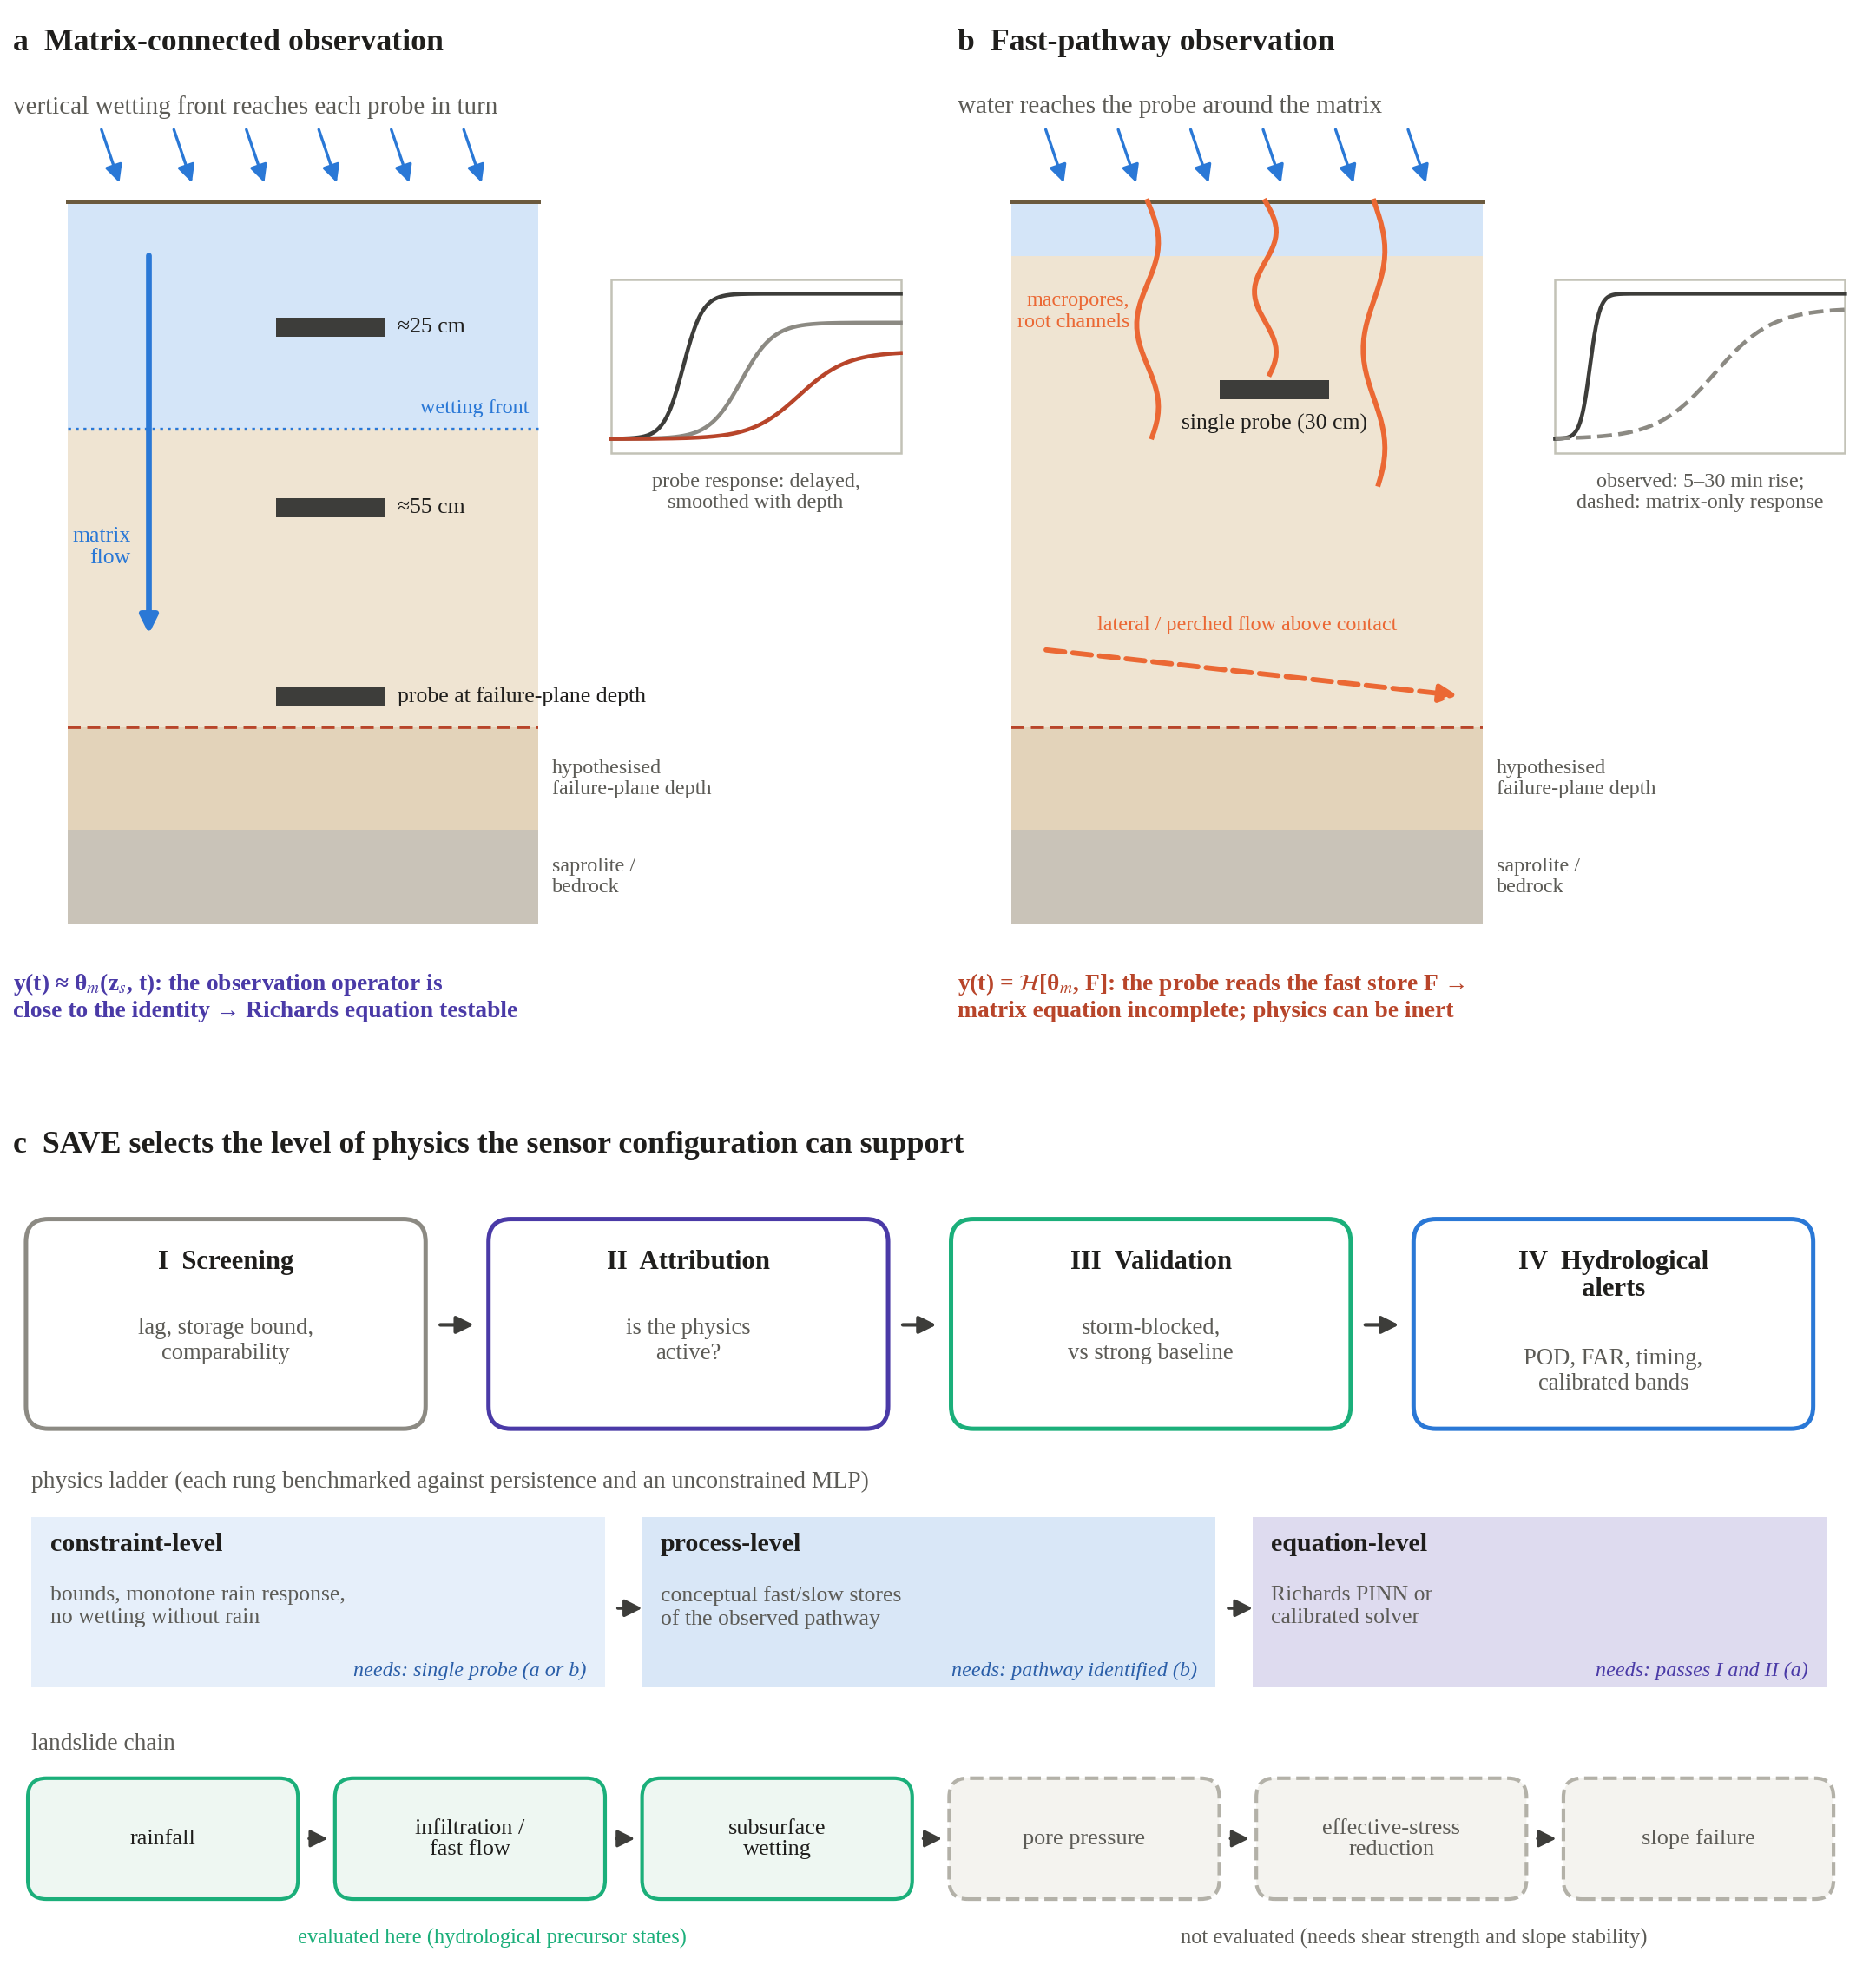

**Fig02**

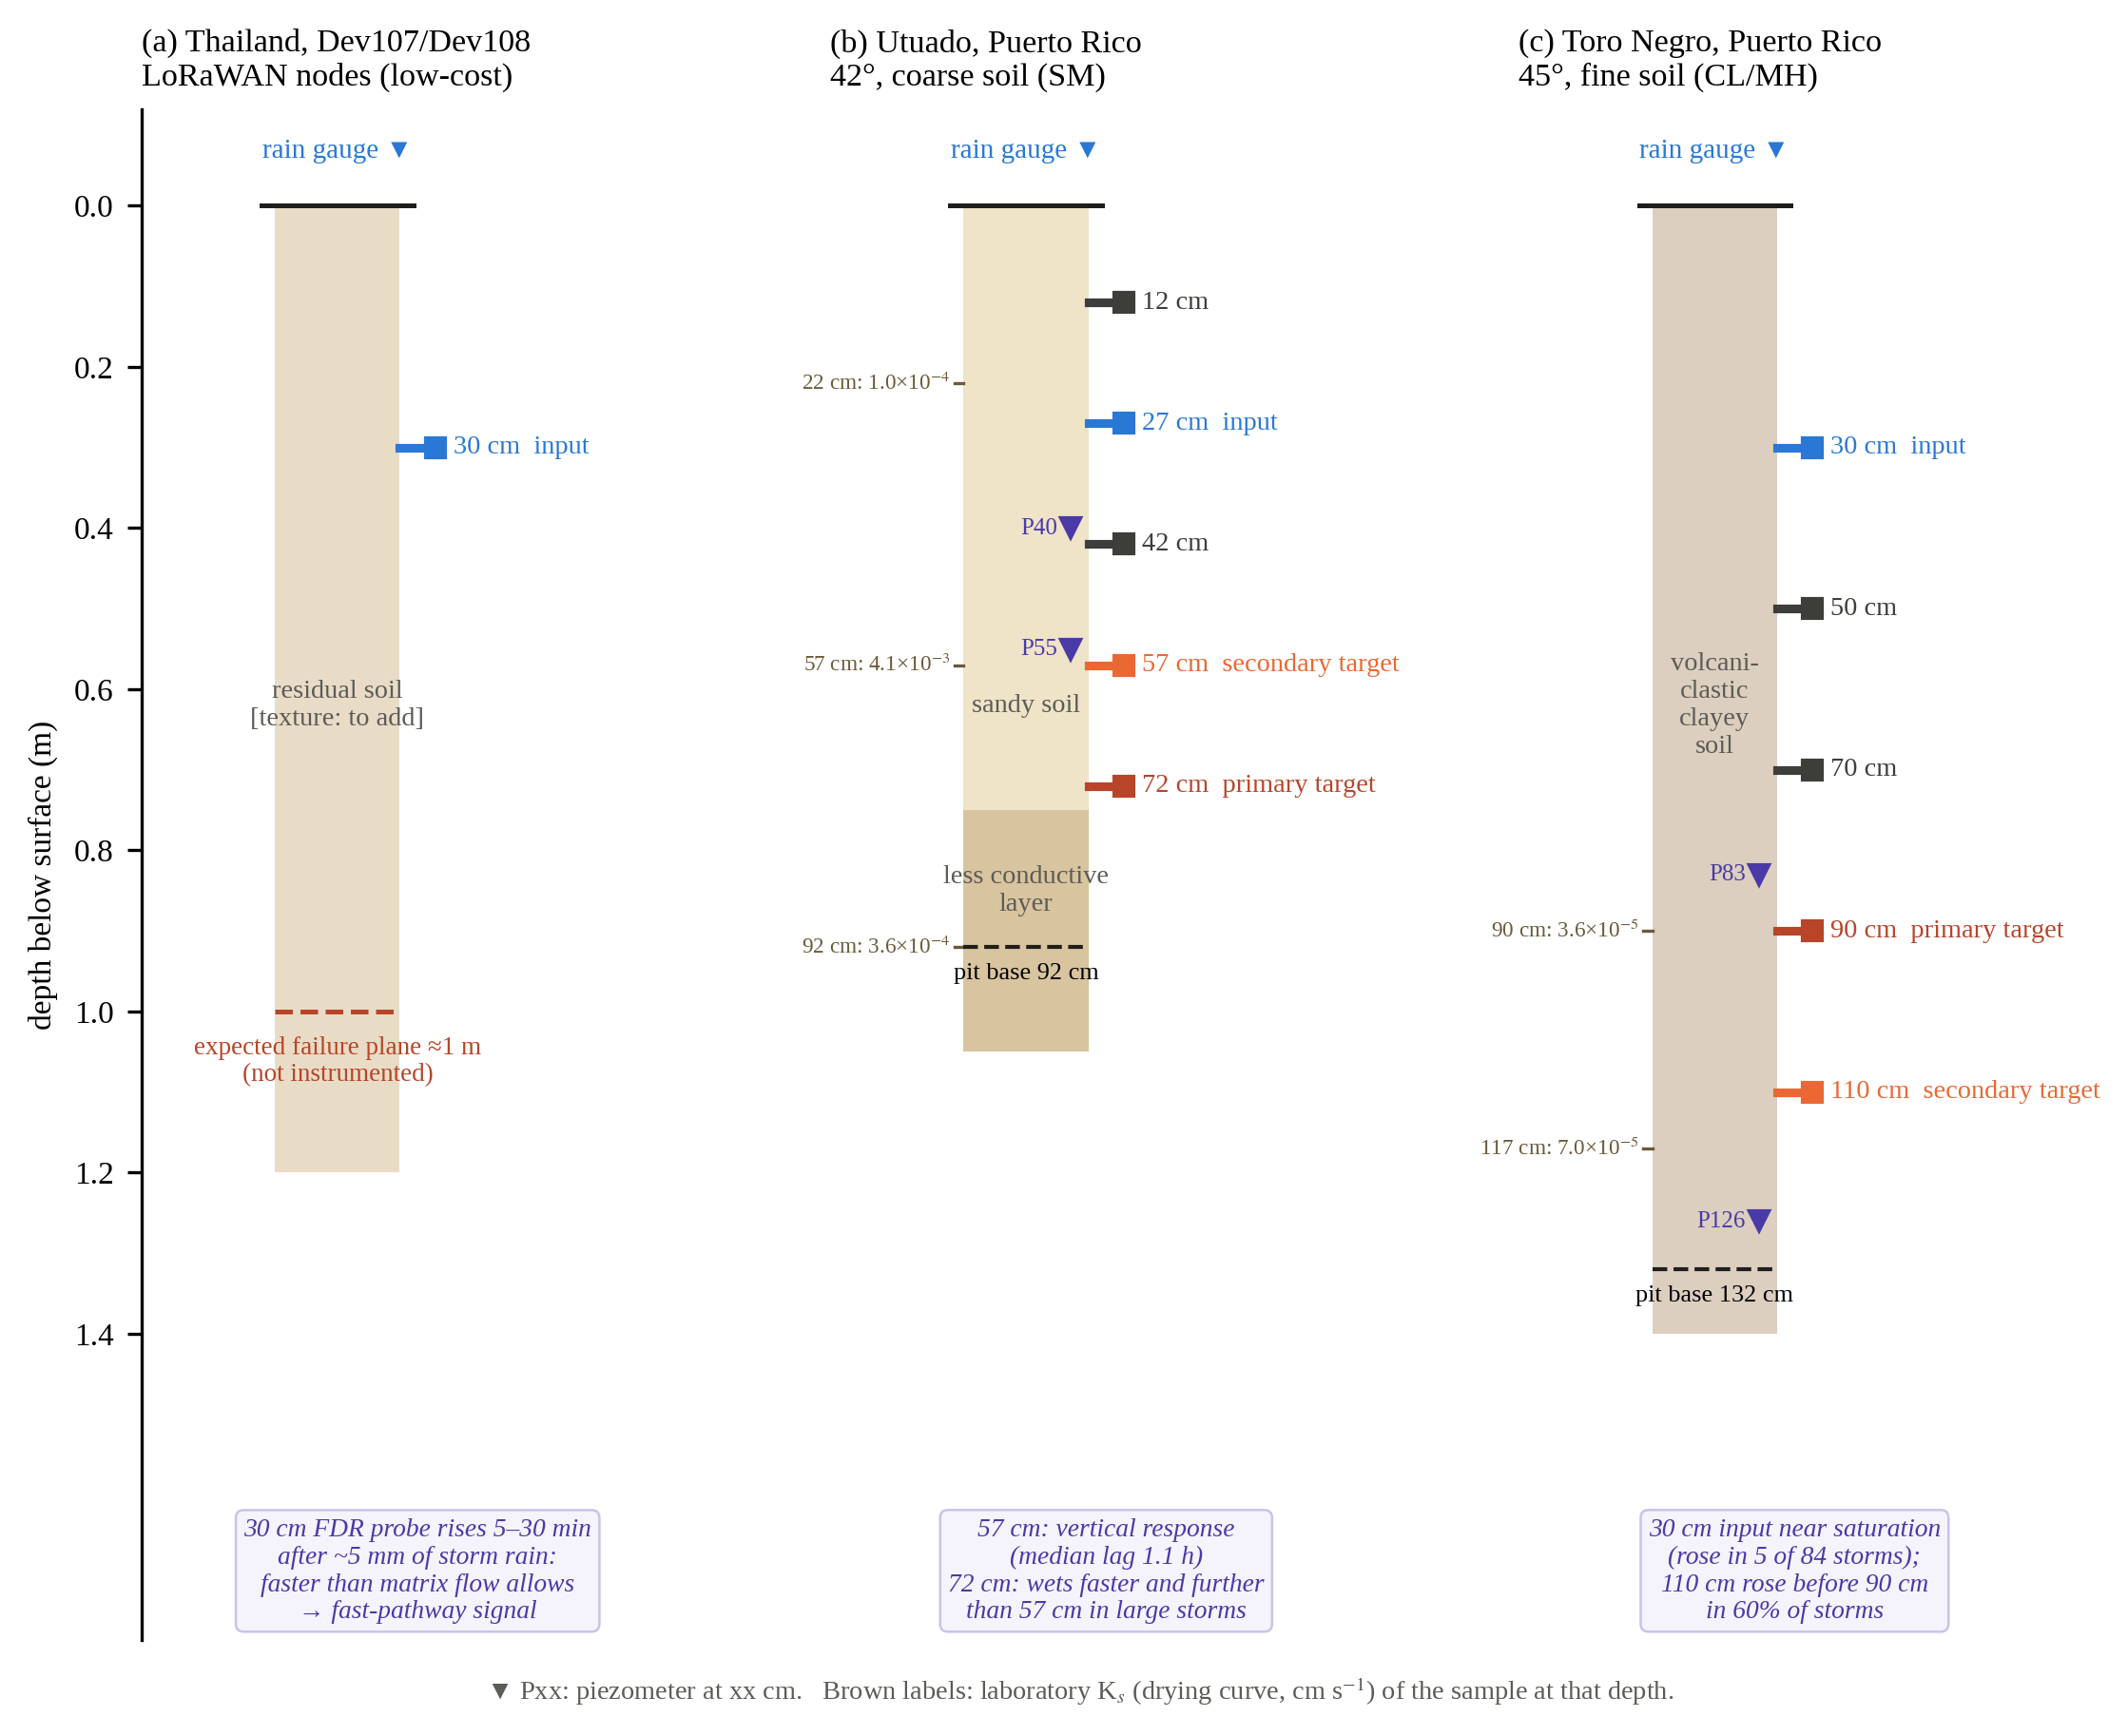

**Fig03**

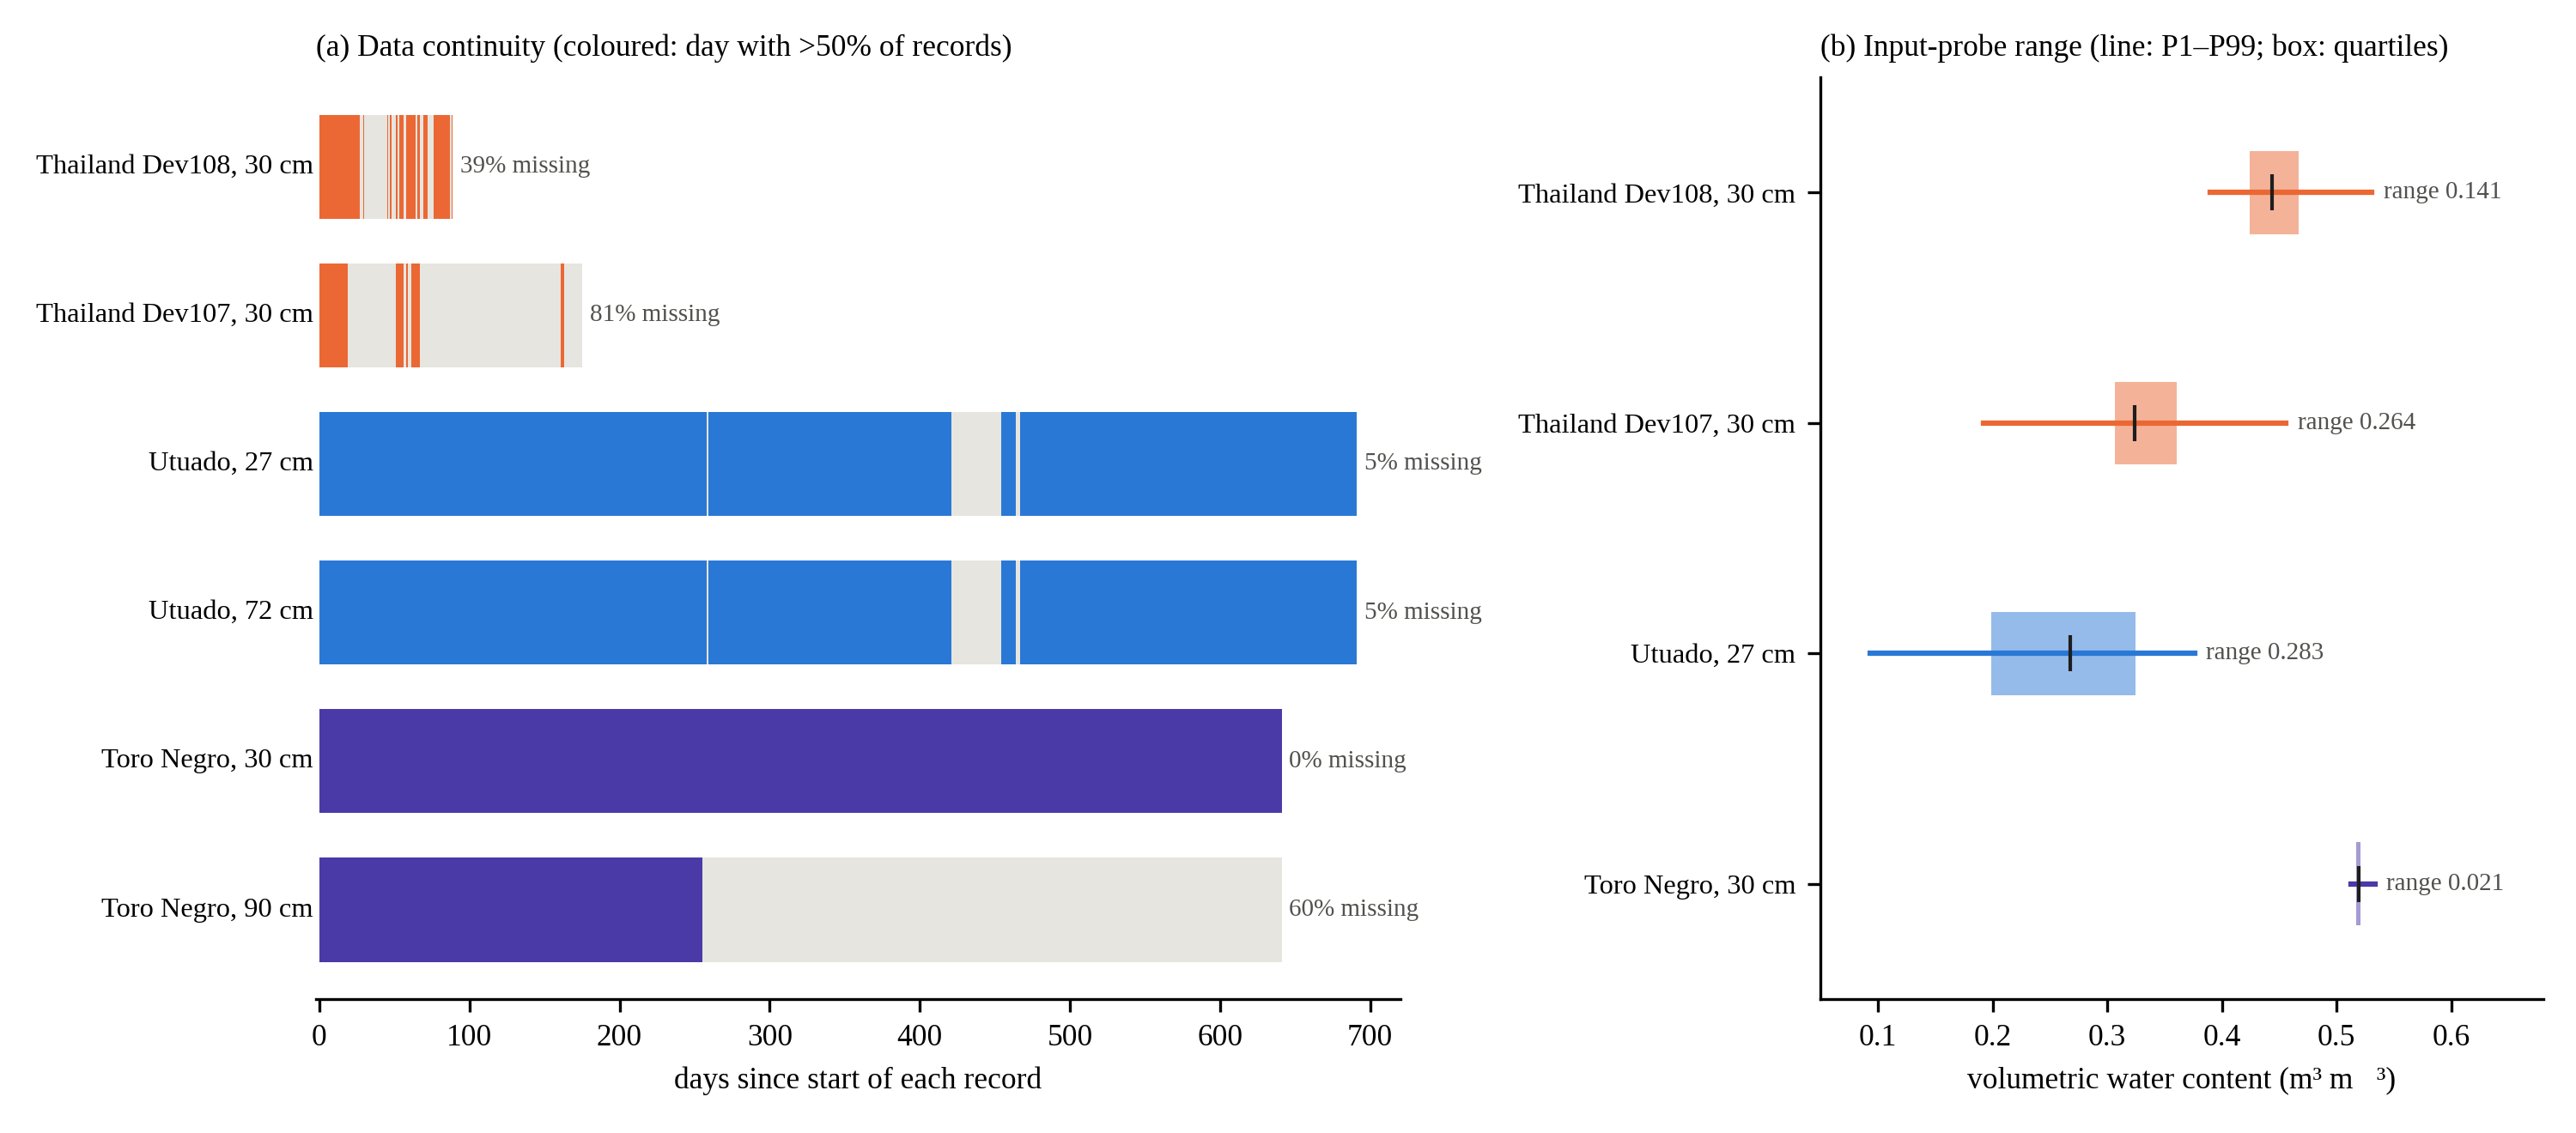

**Fig04**

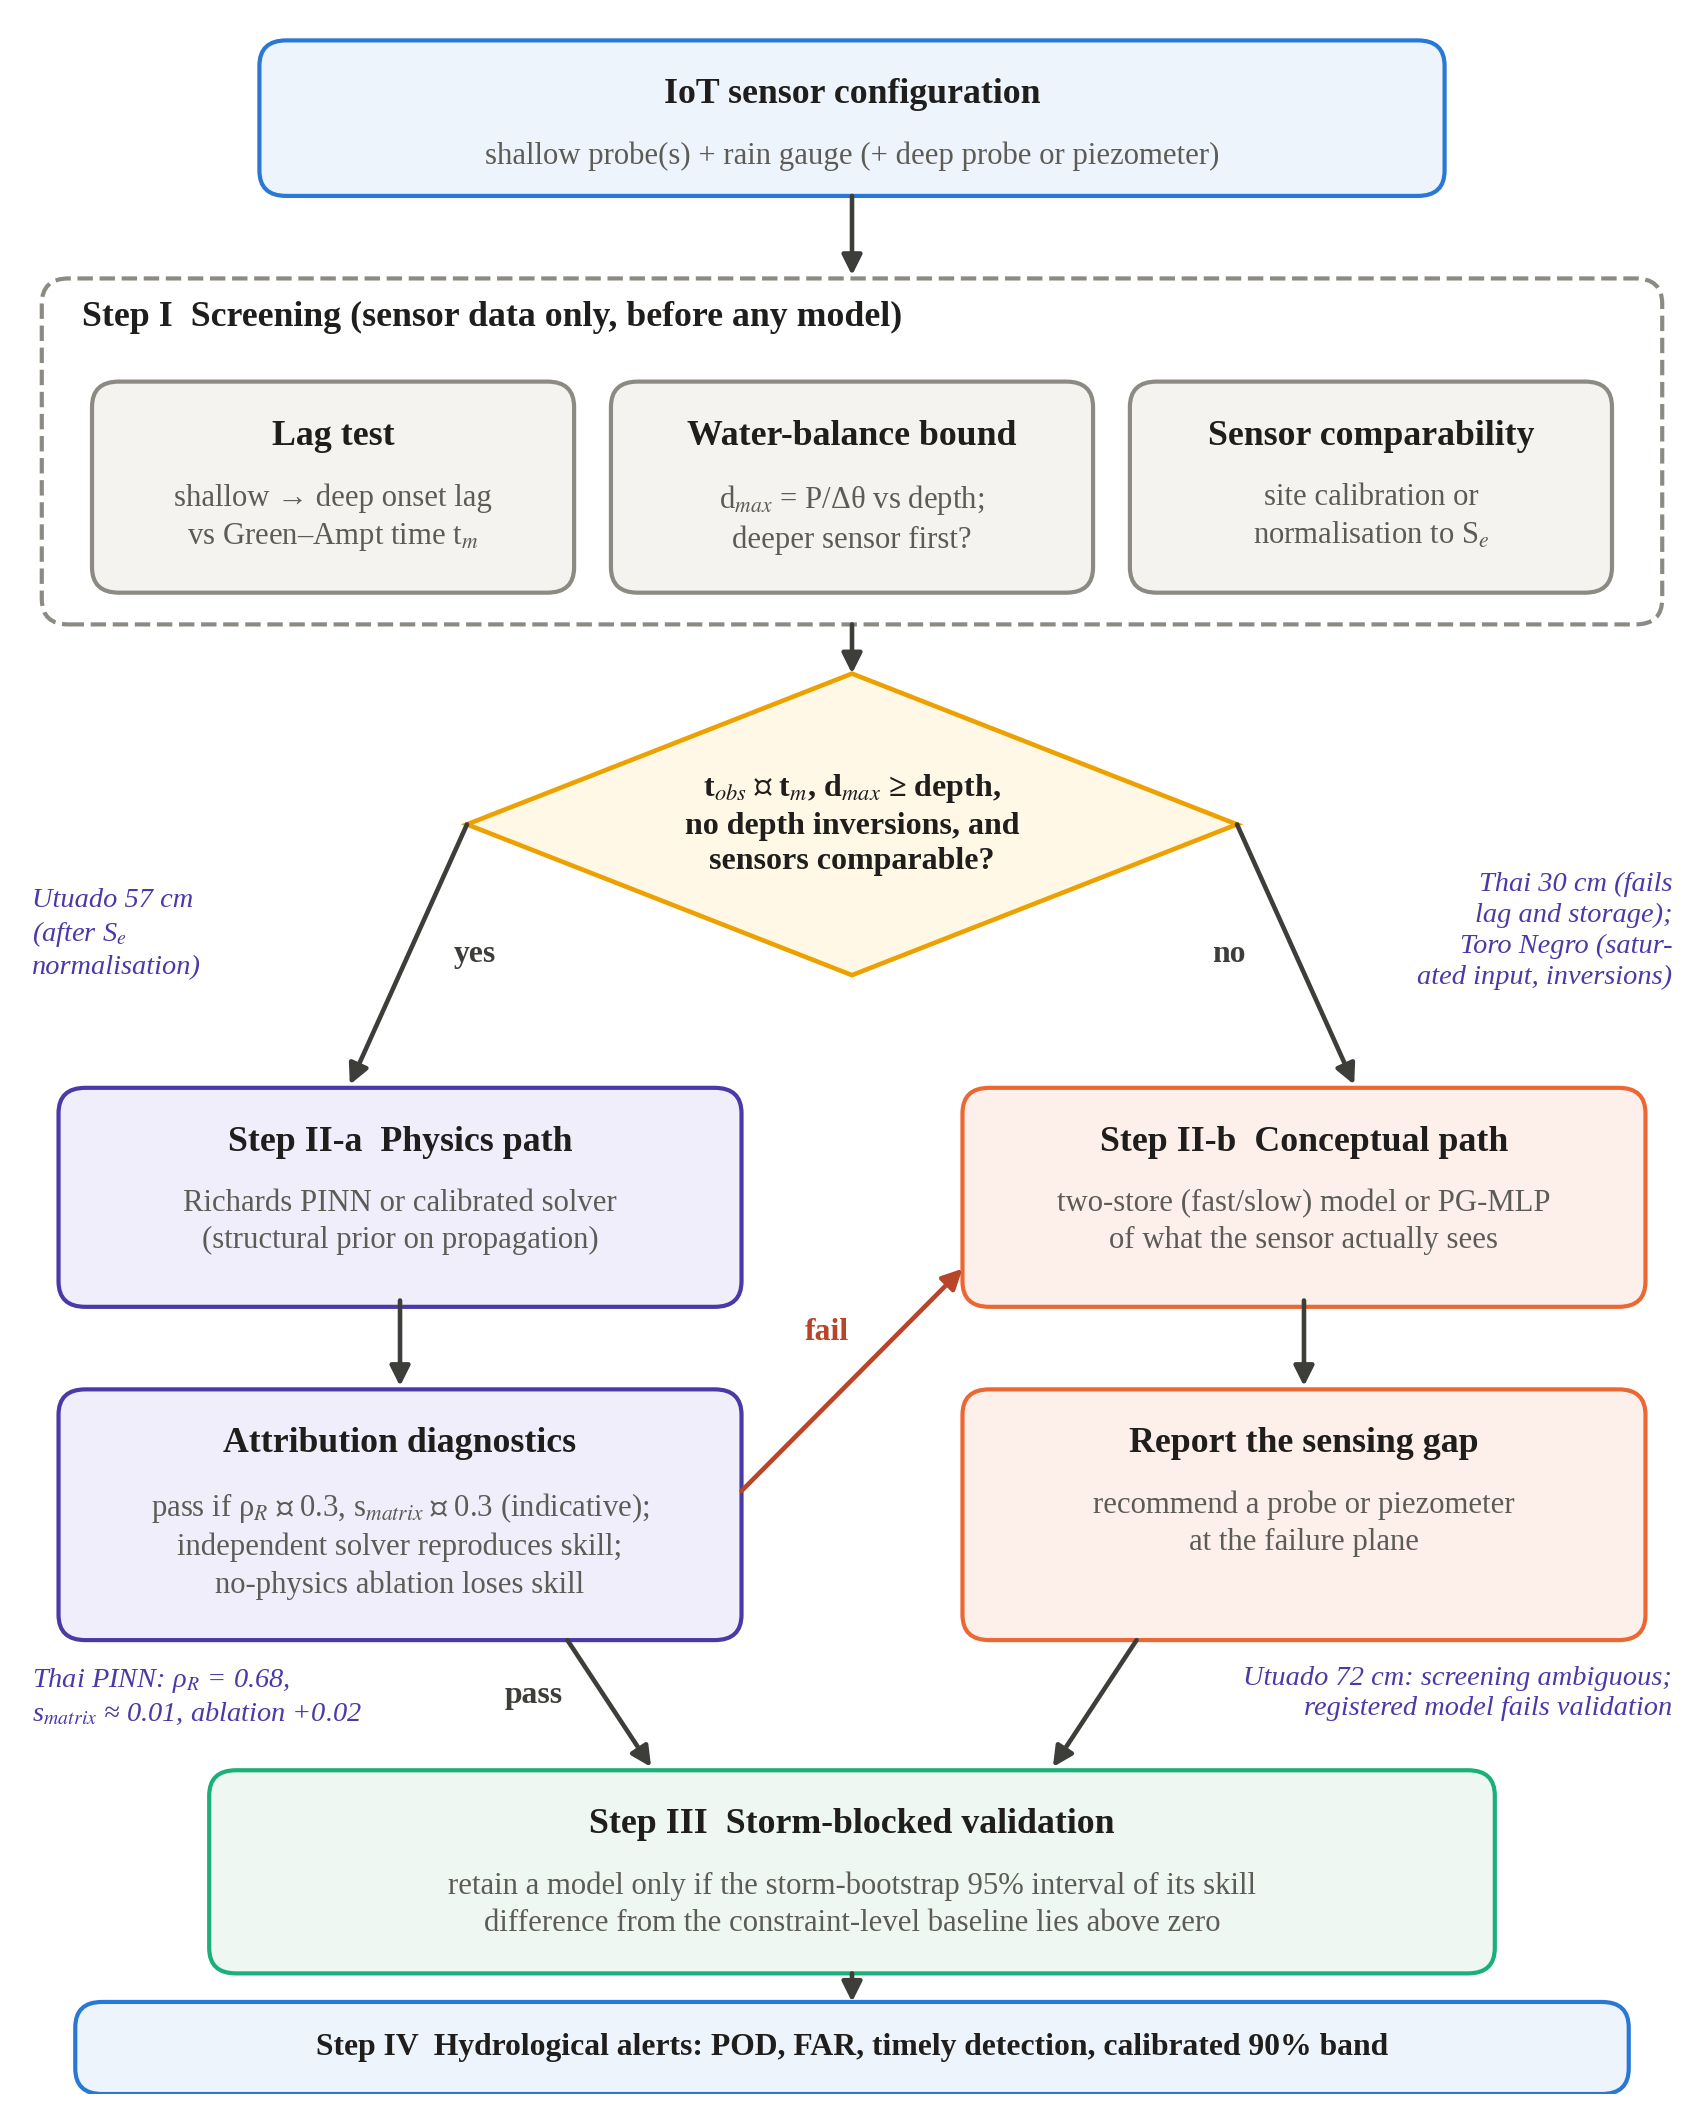

**Fig05**

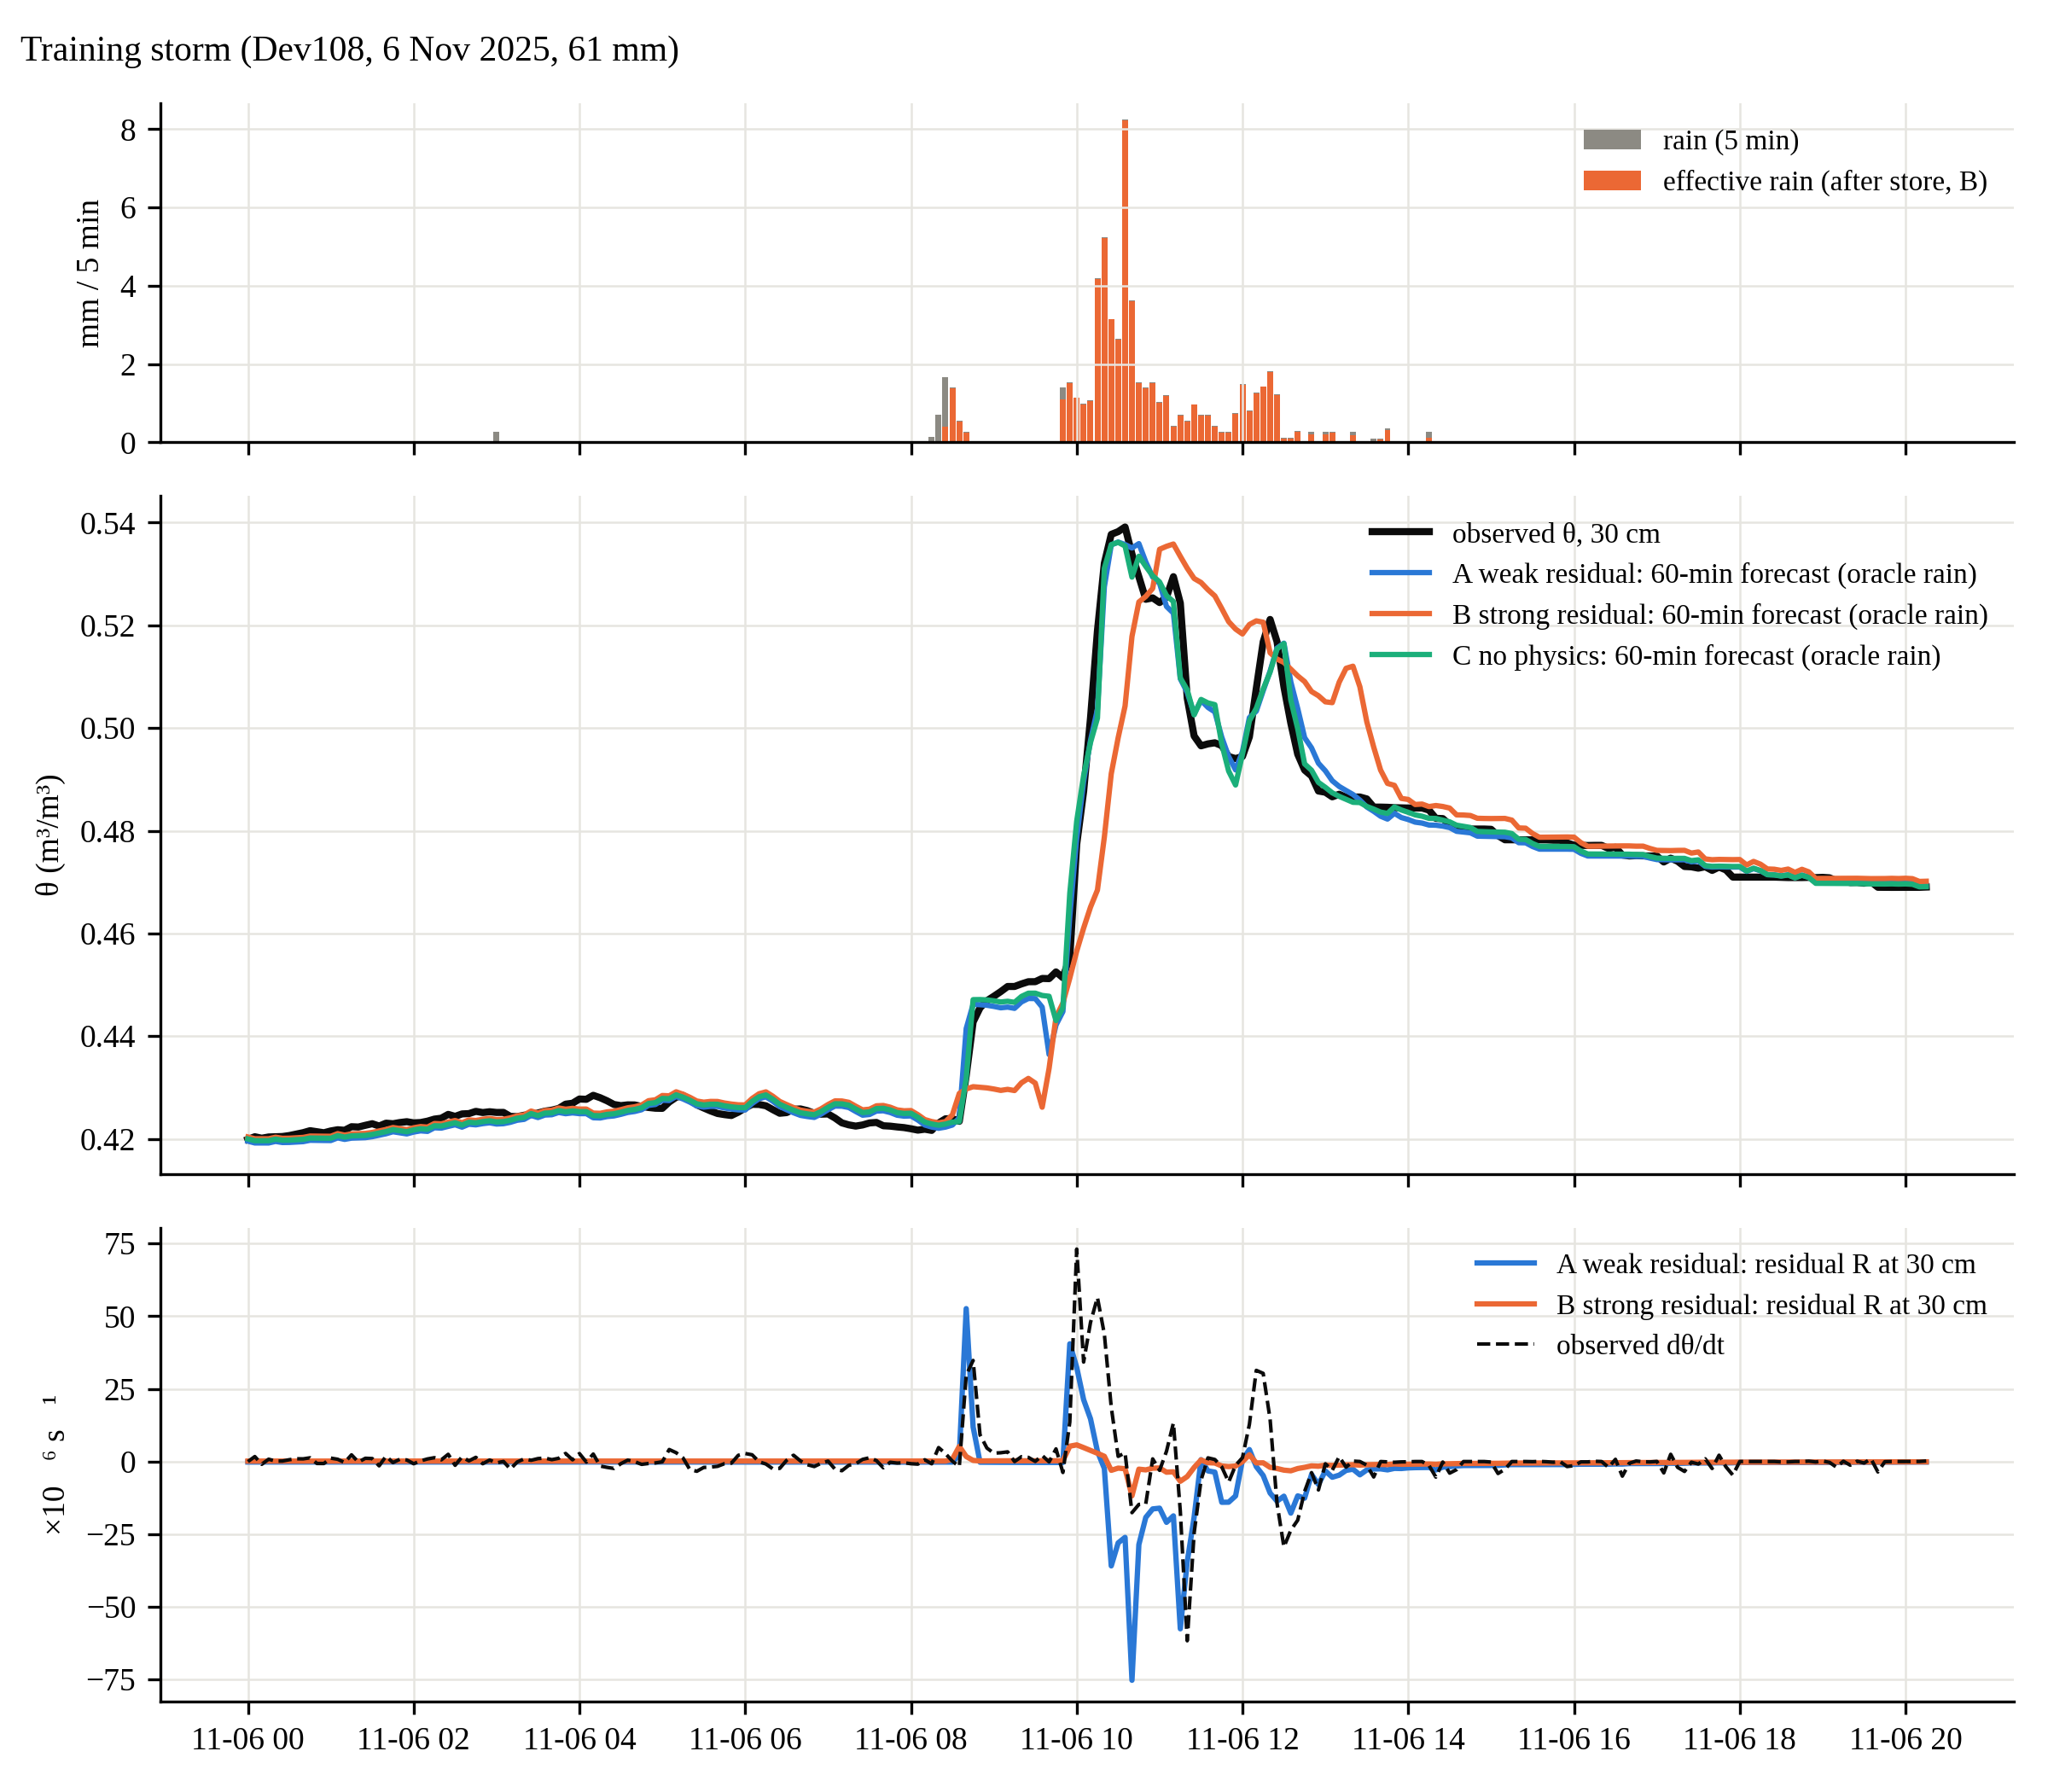

**Fig06**

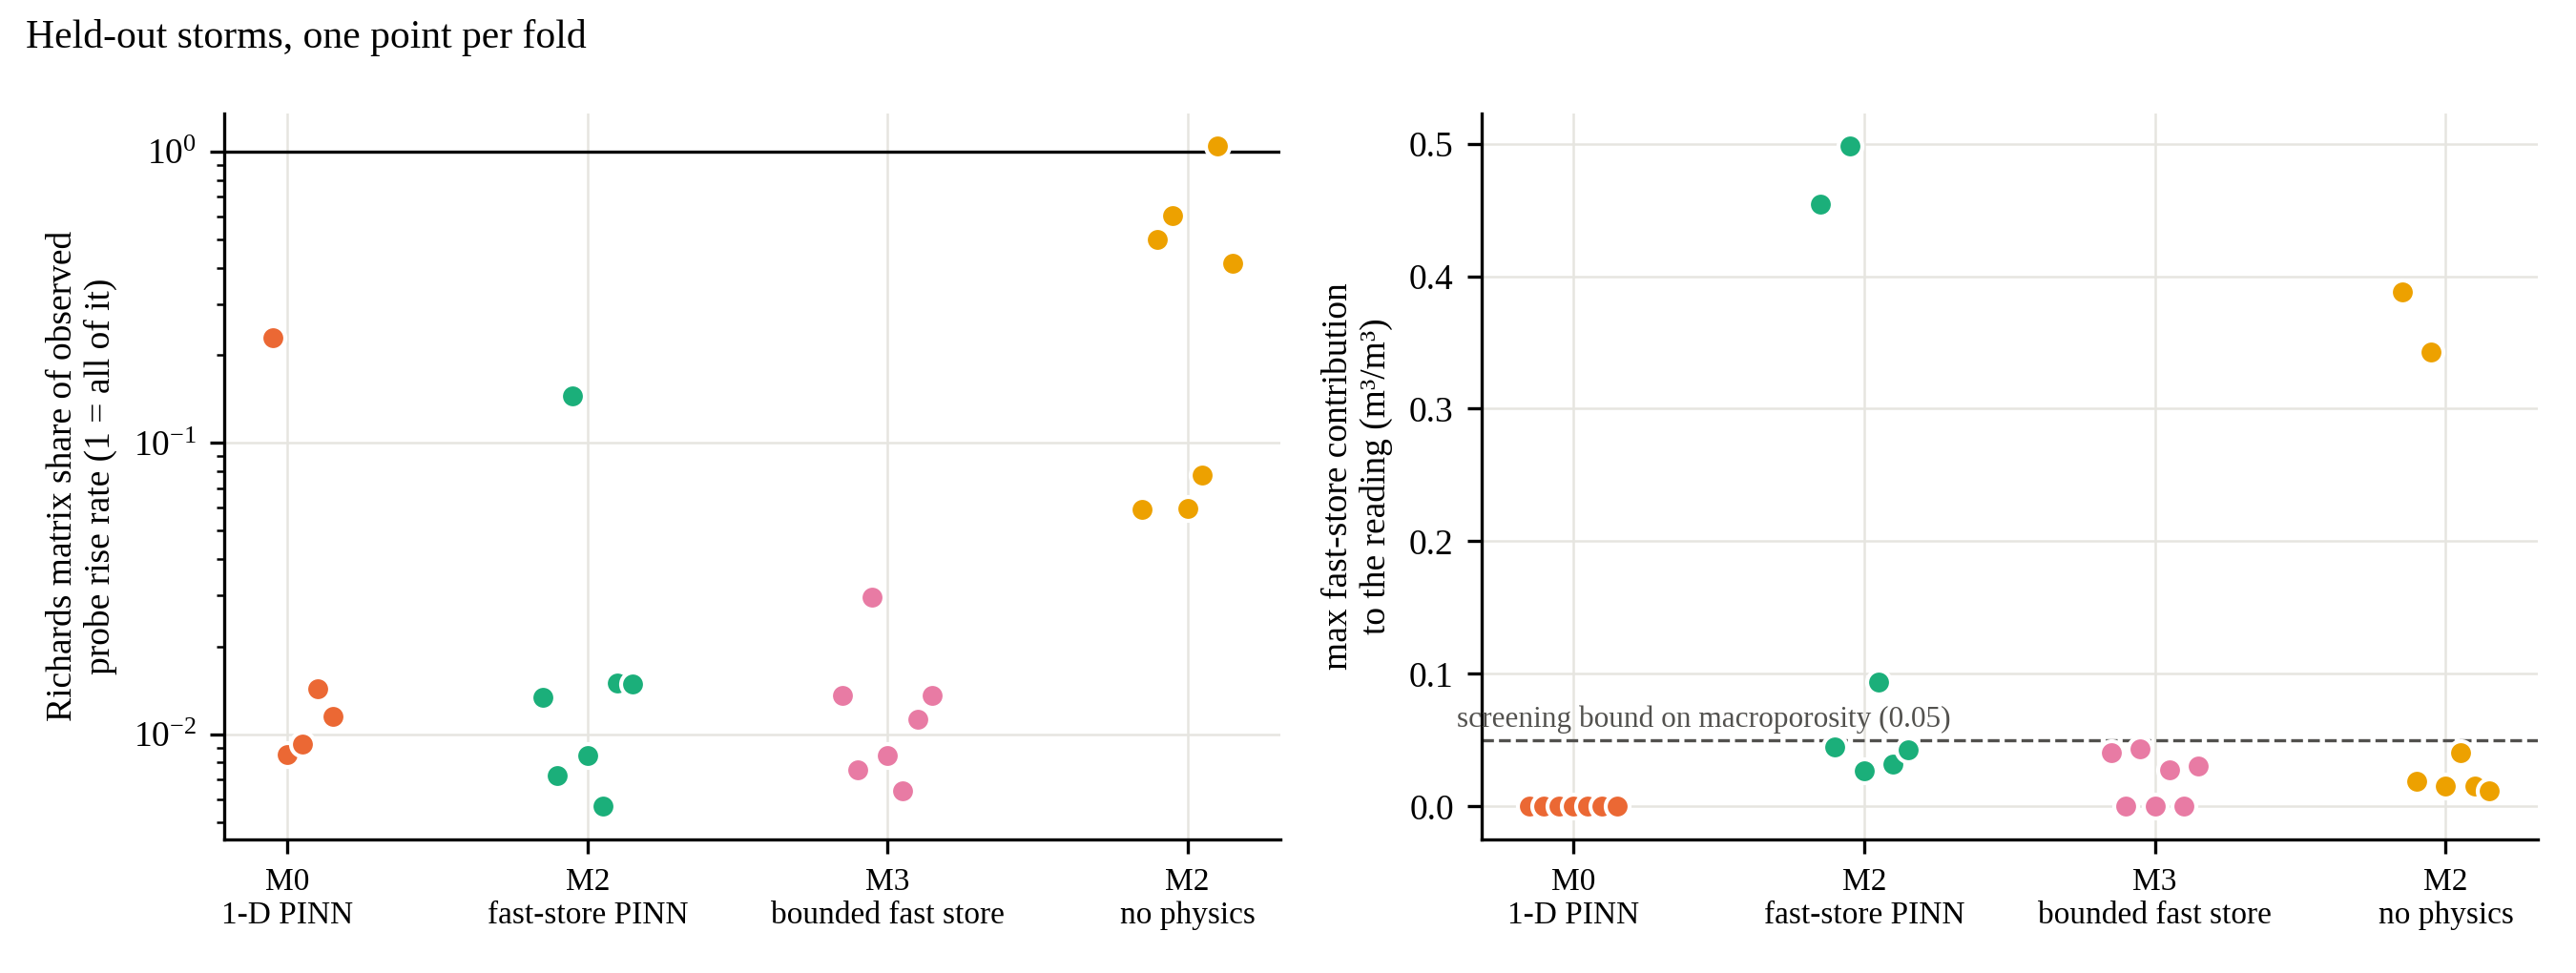

**Fig07**

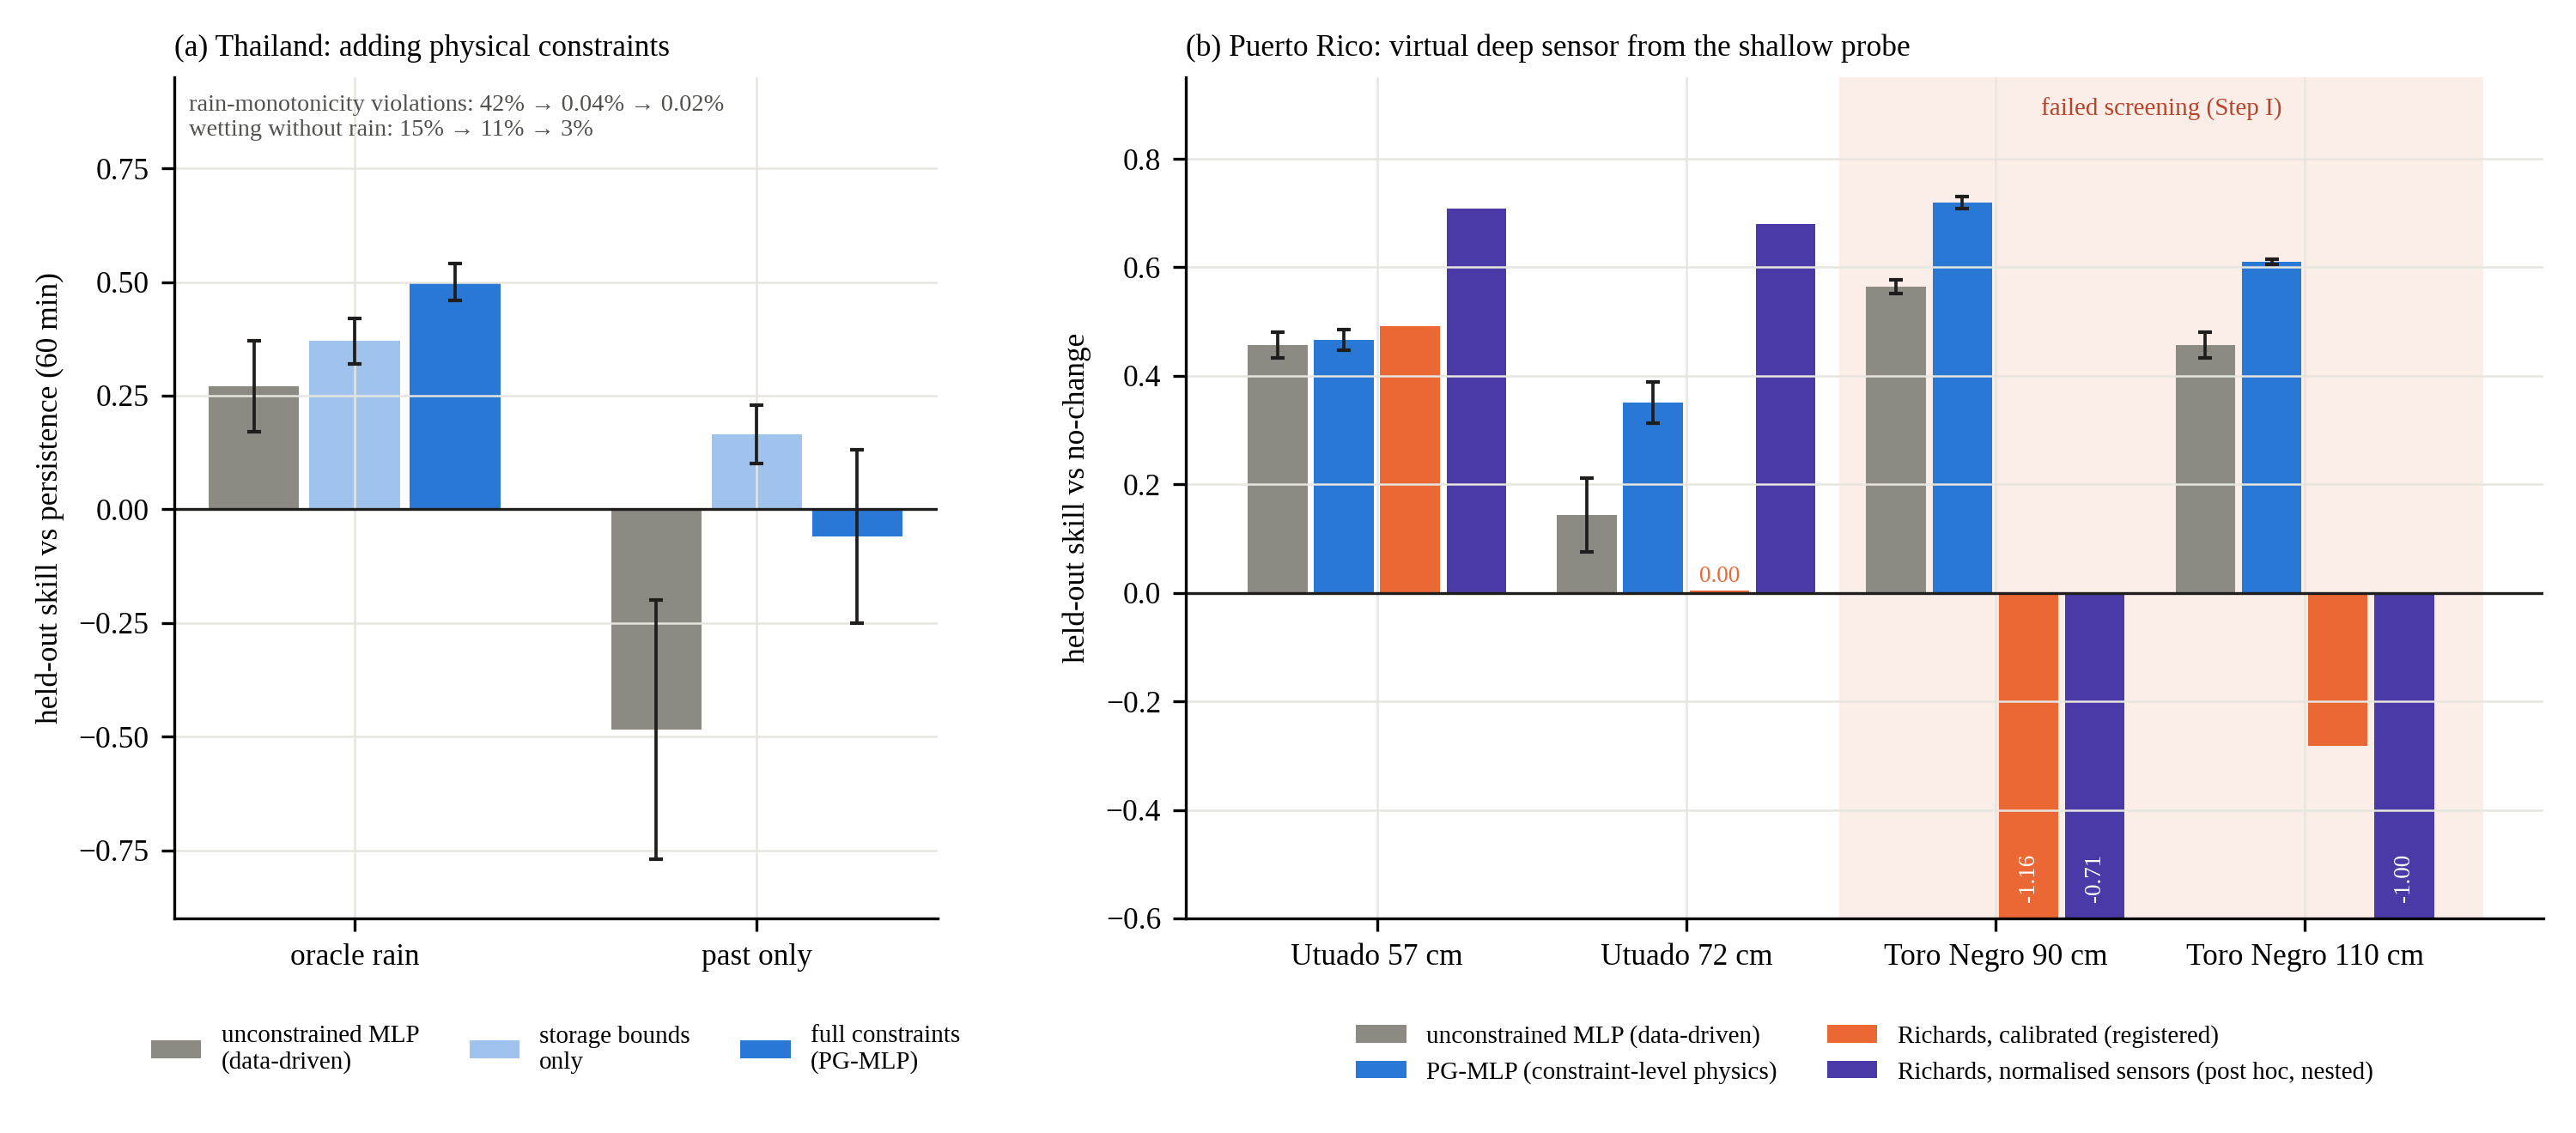

**Fig08**

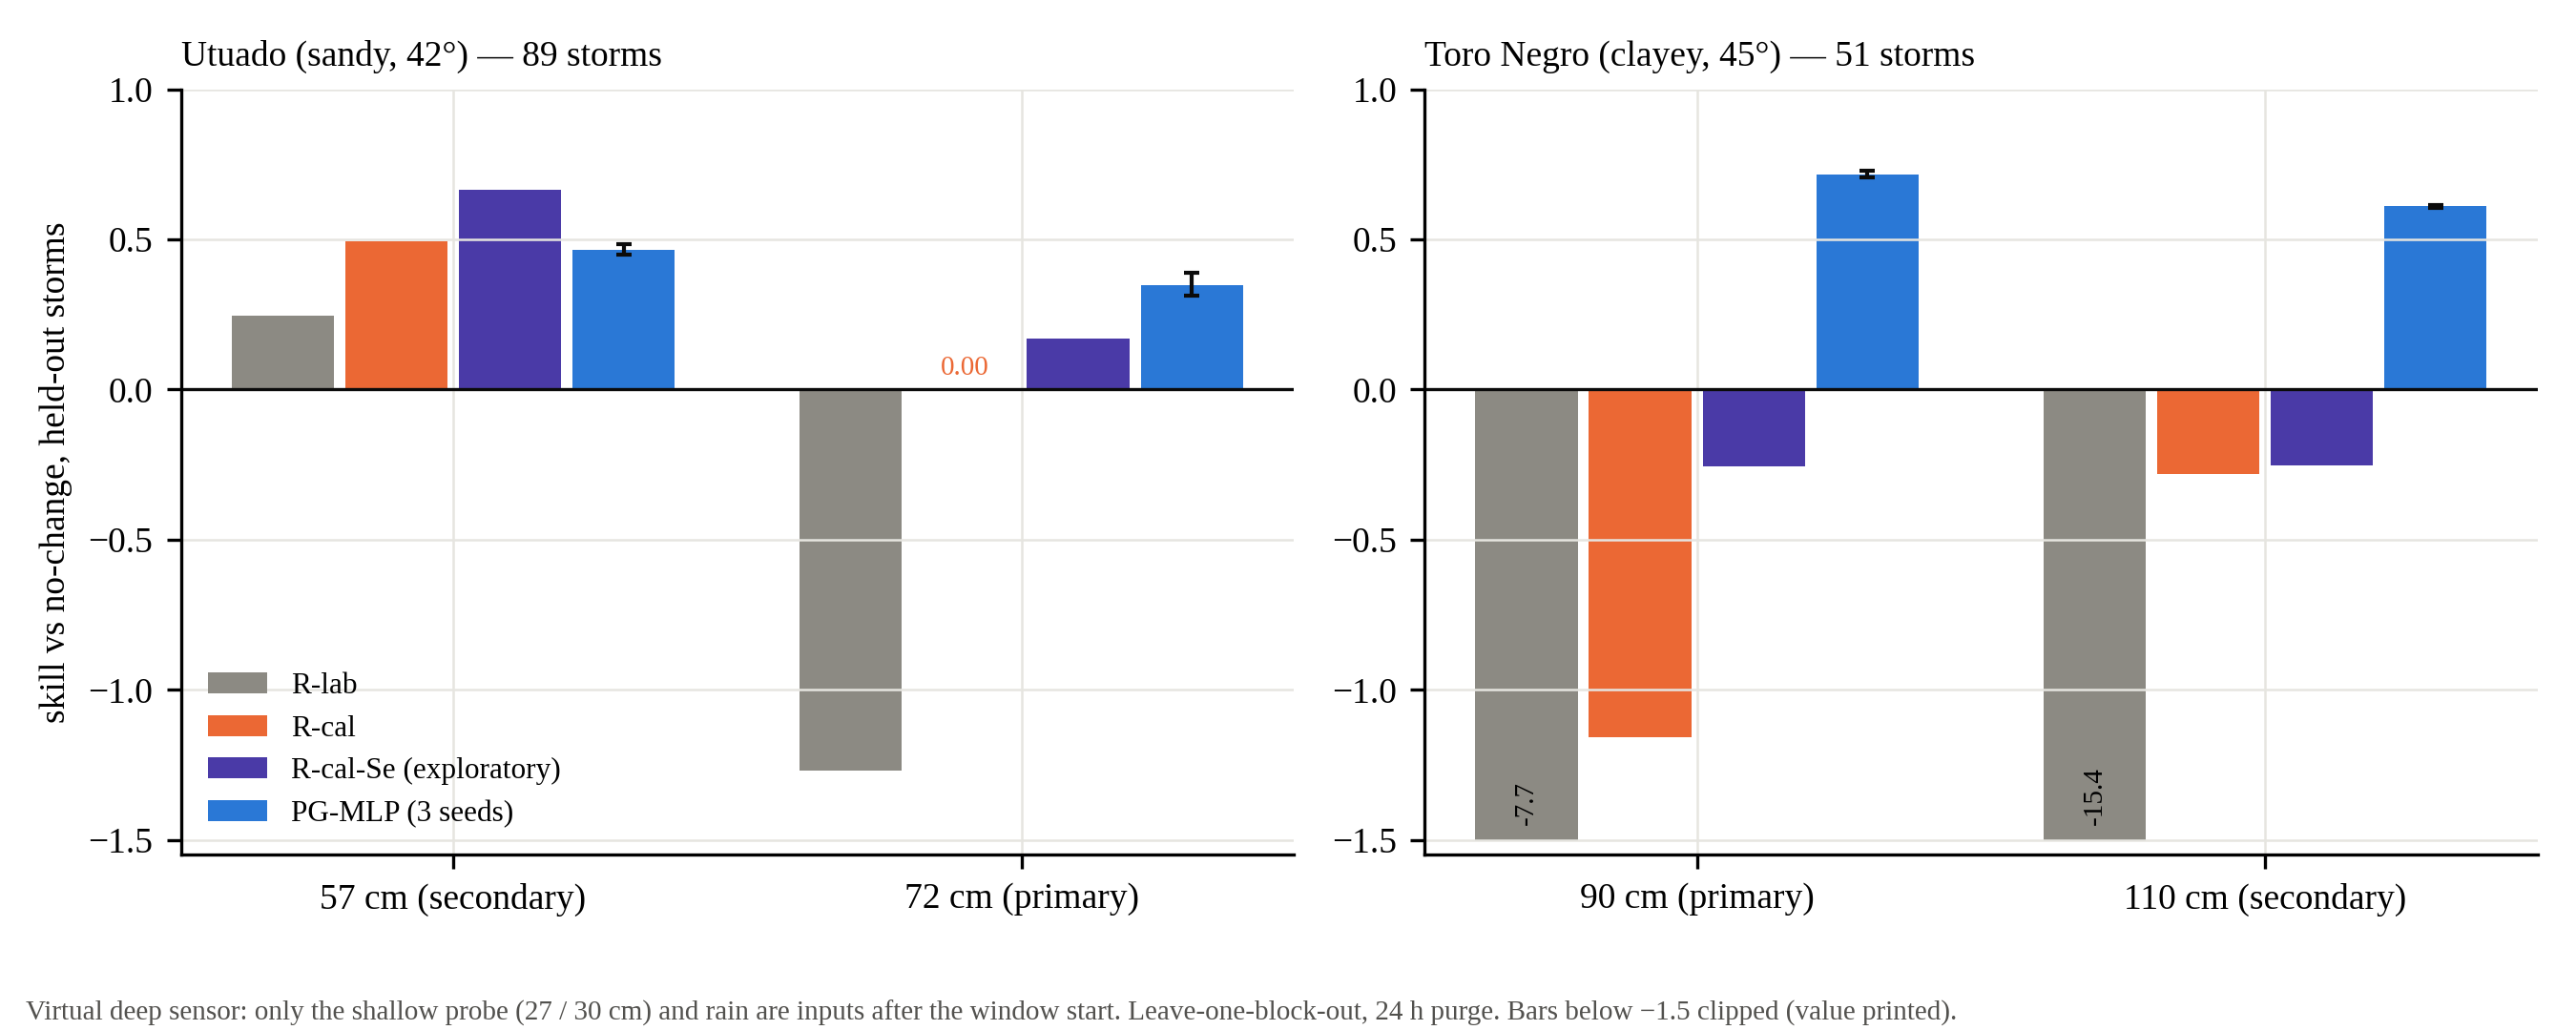

**Fig09**

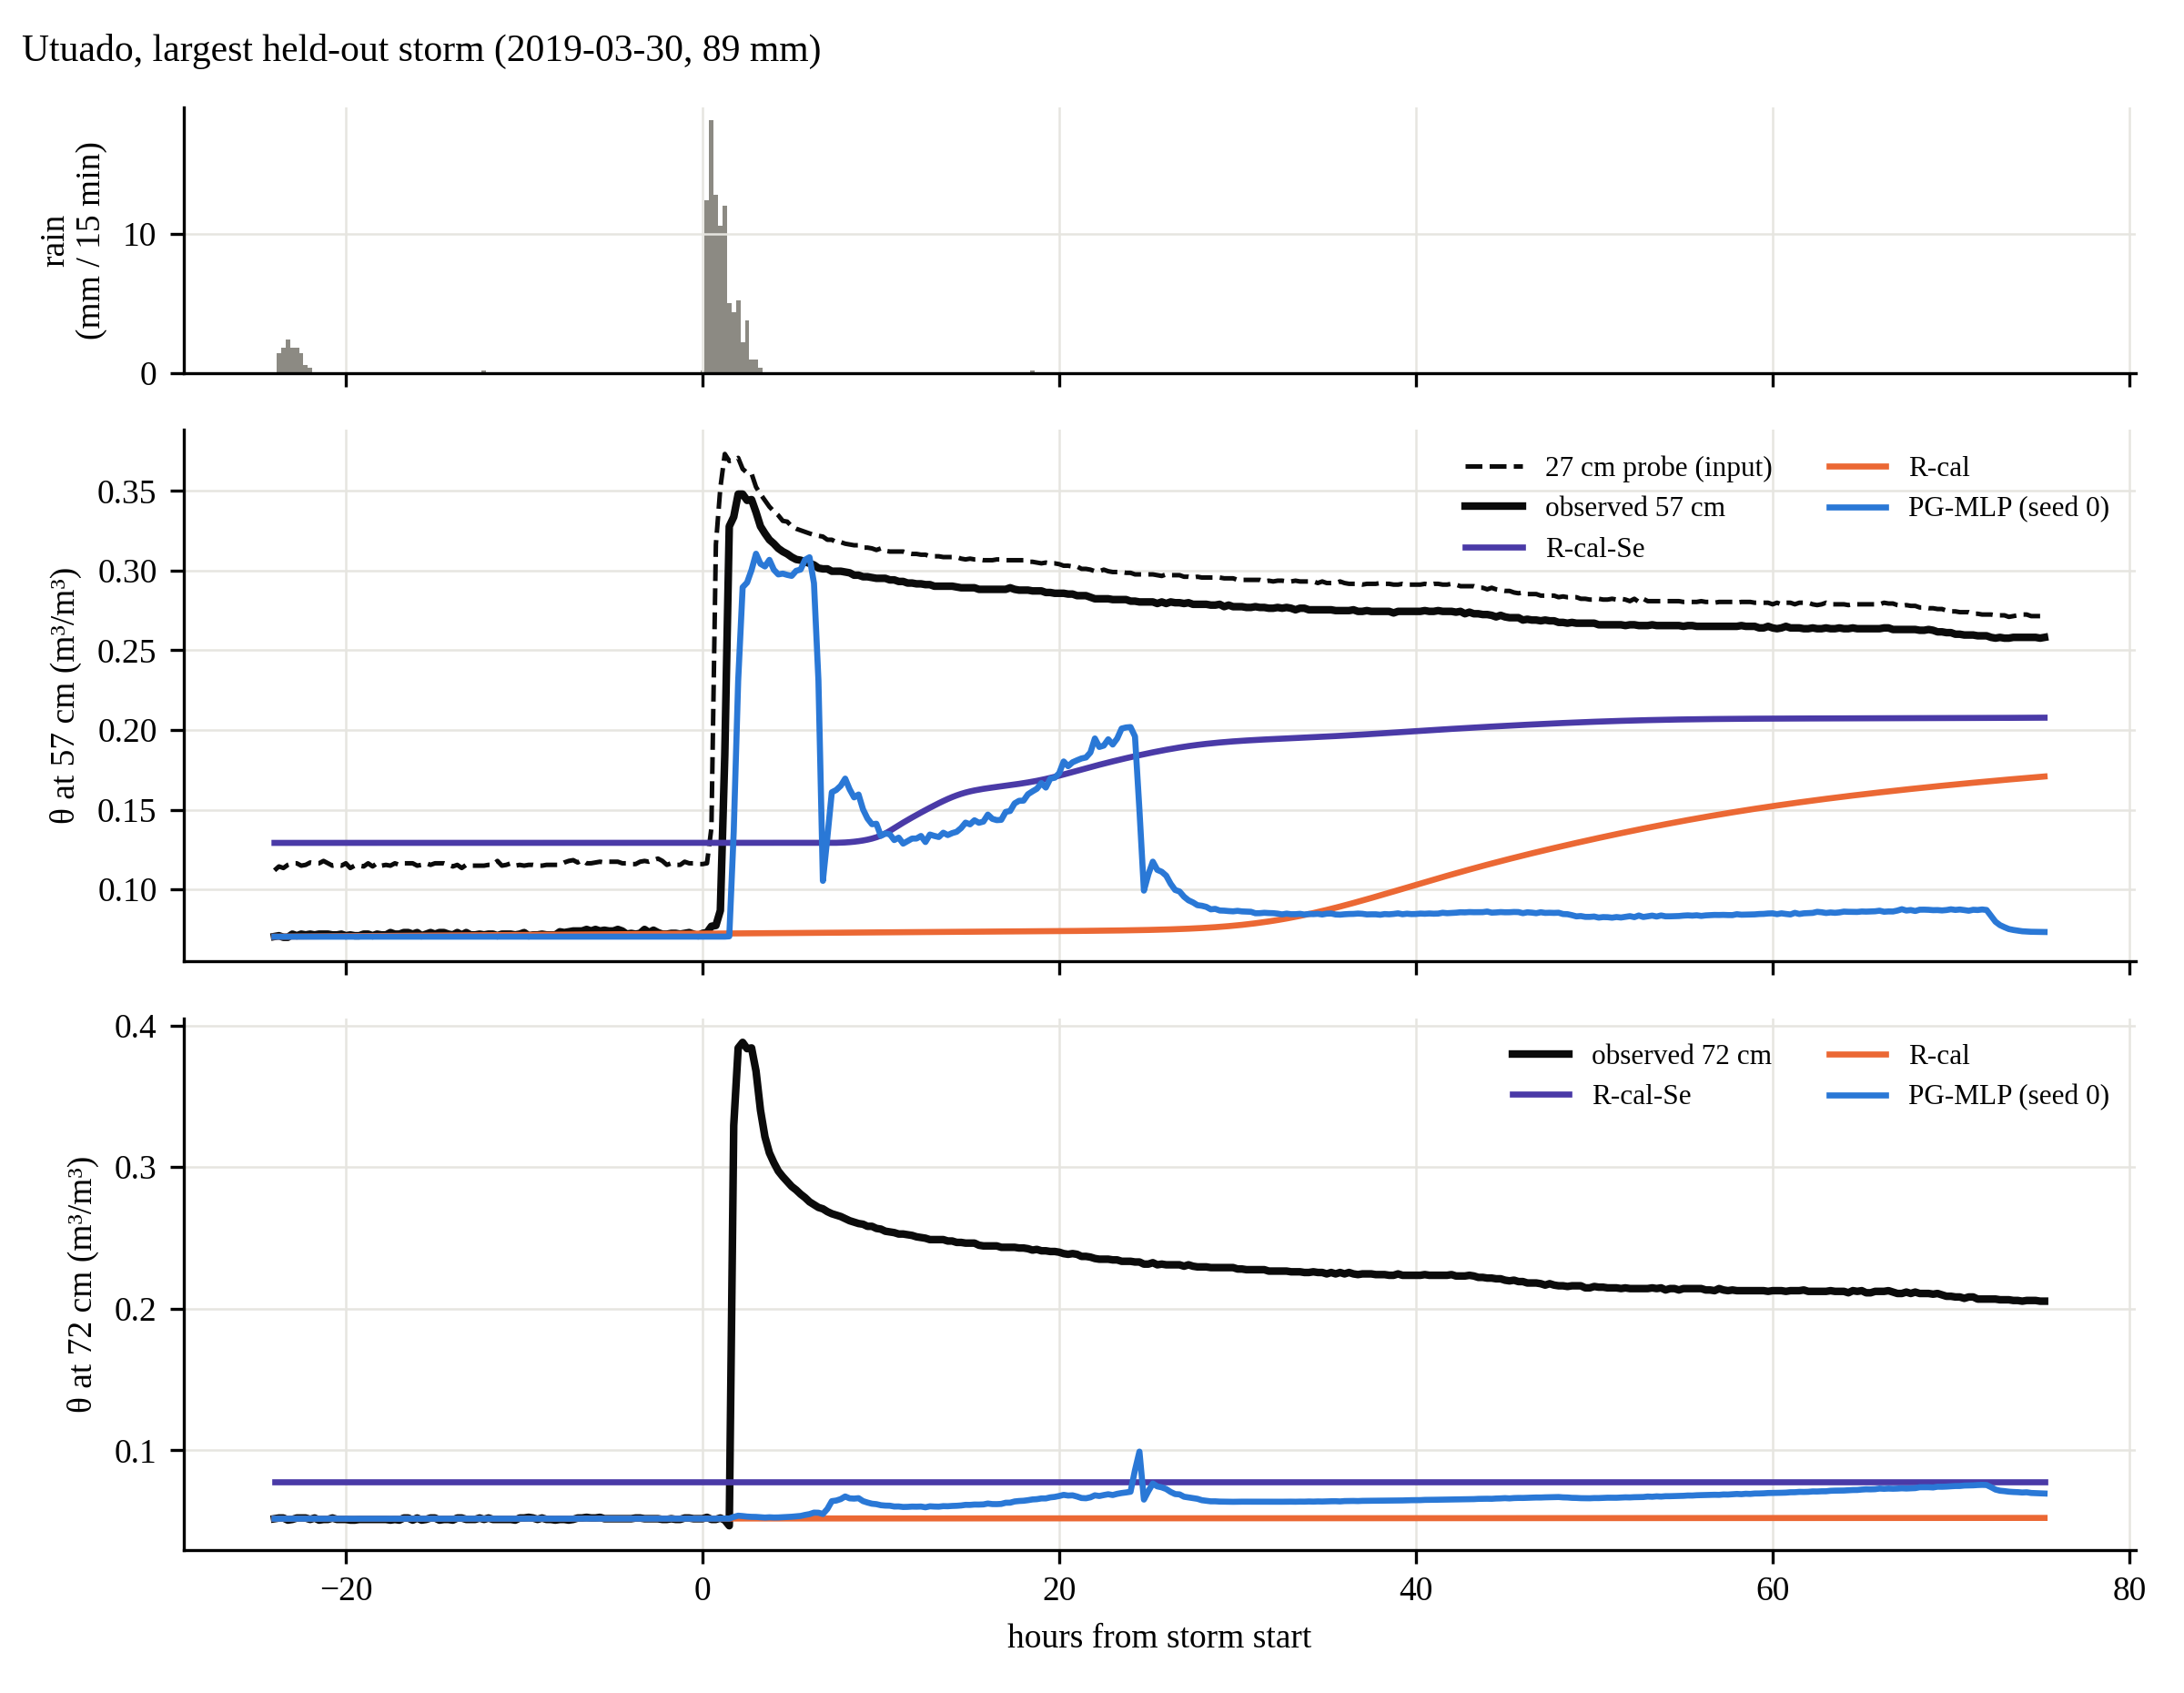

**Fig10**

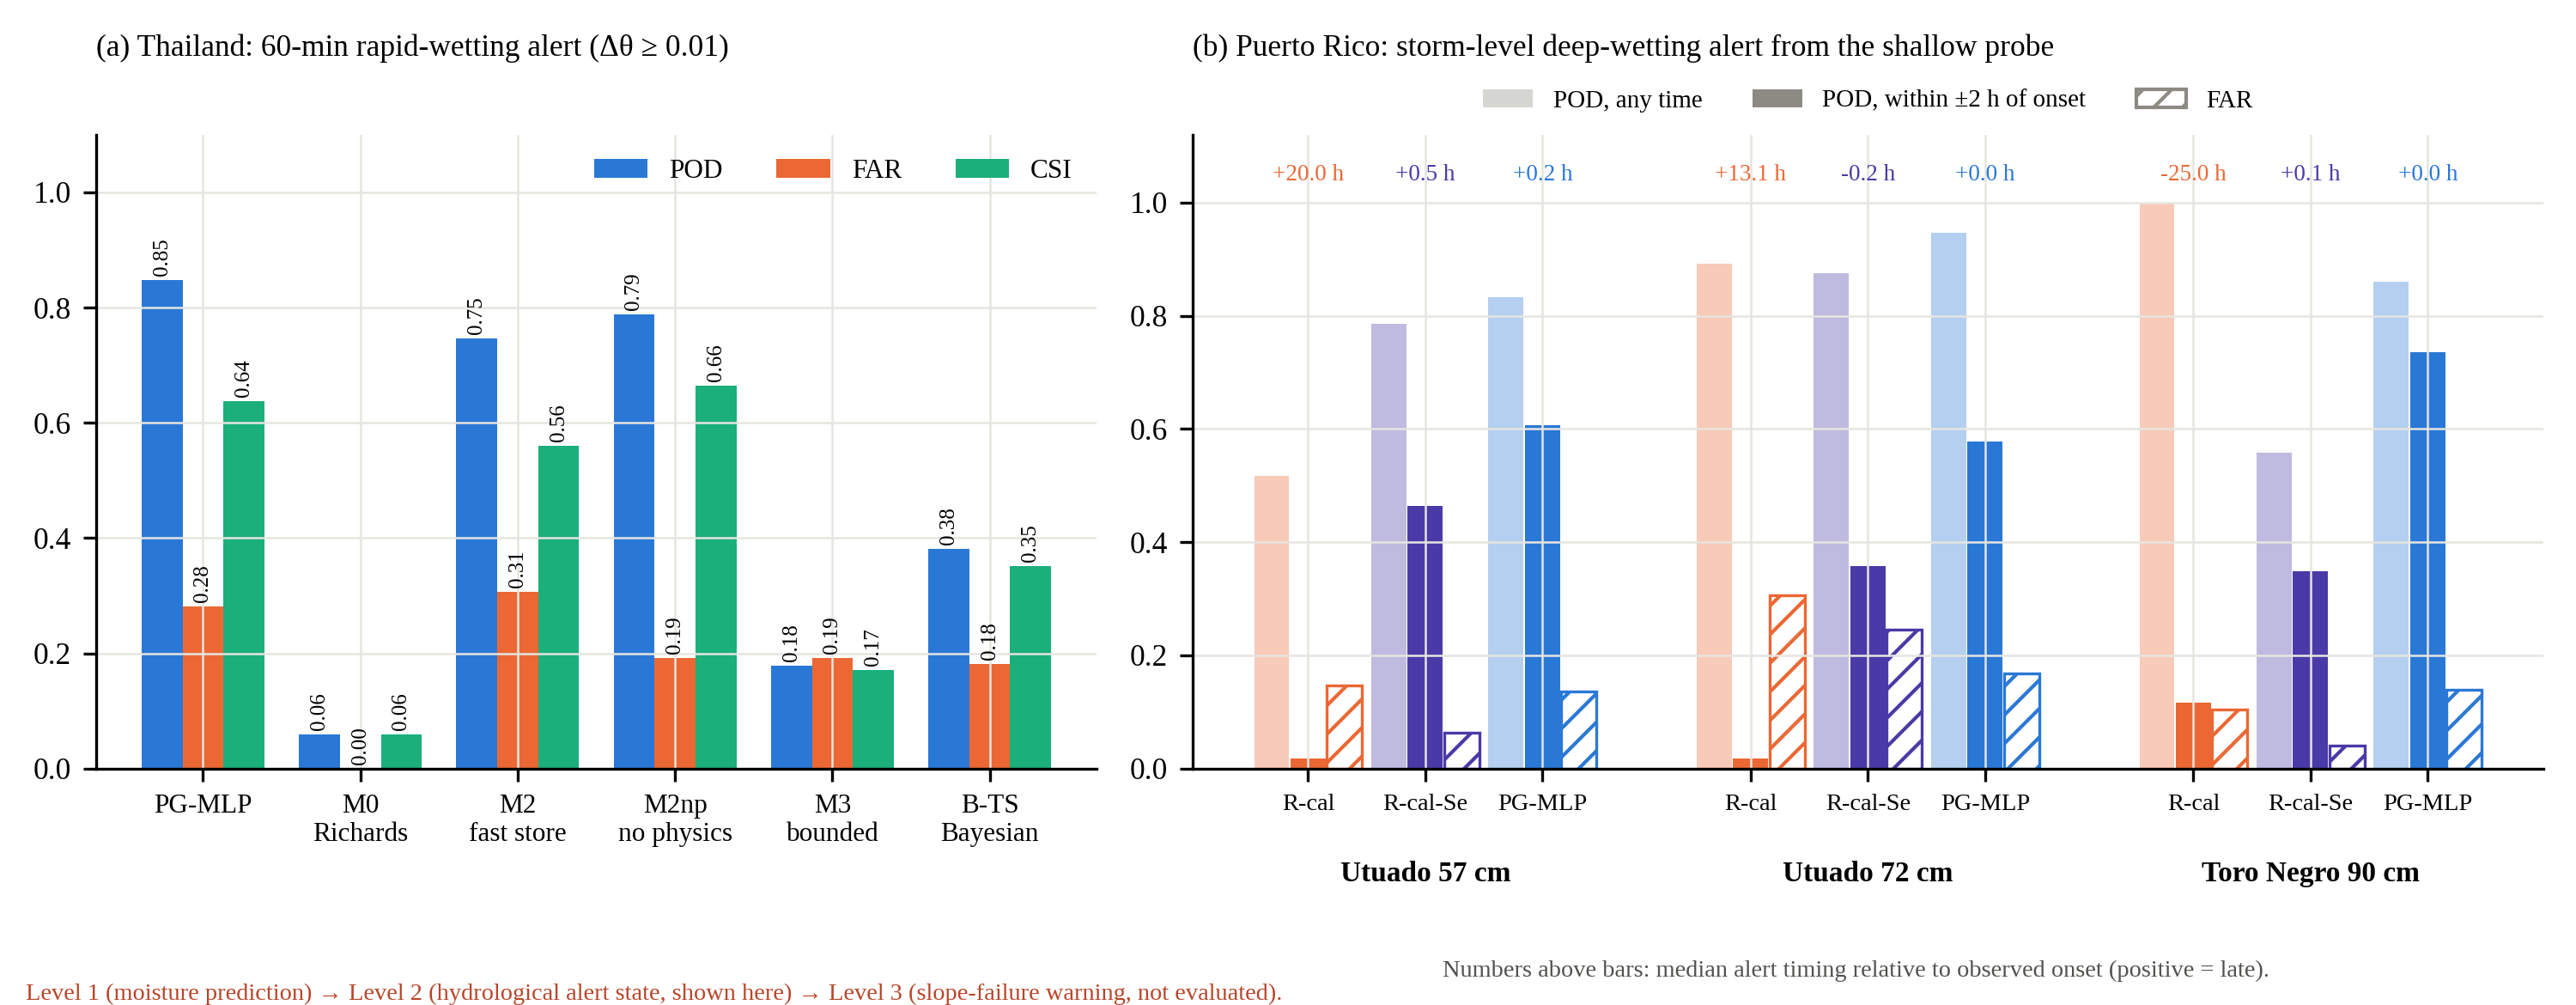

**Fig11**

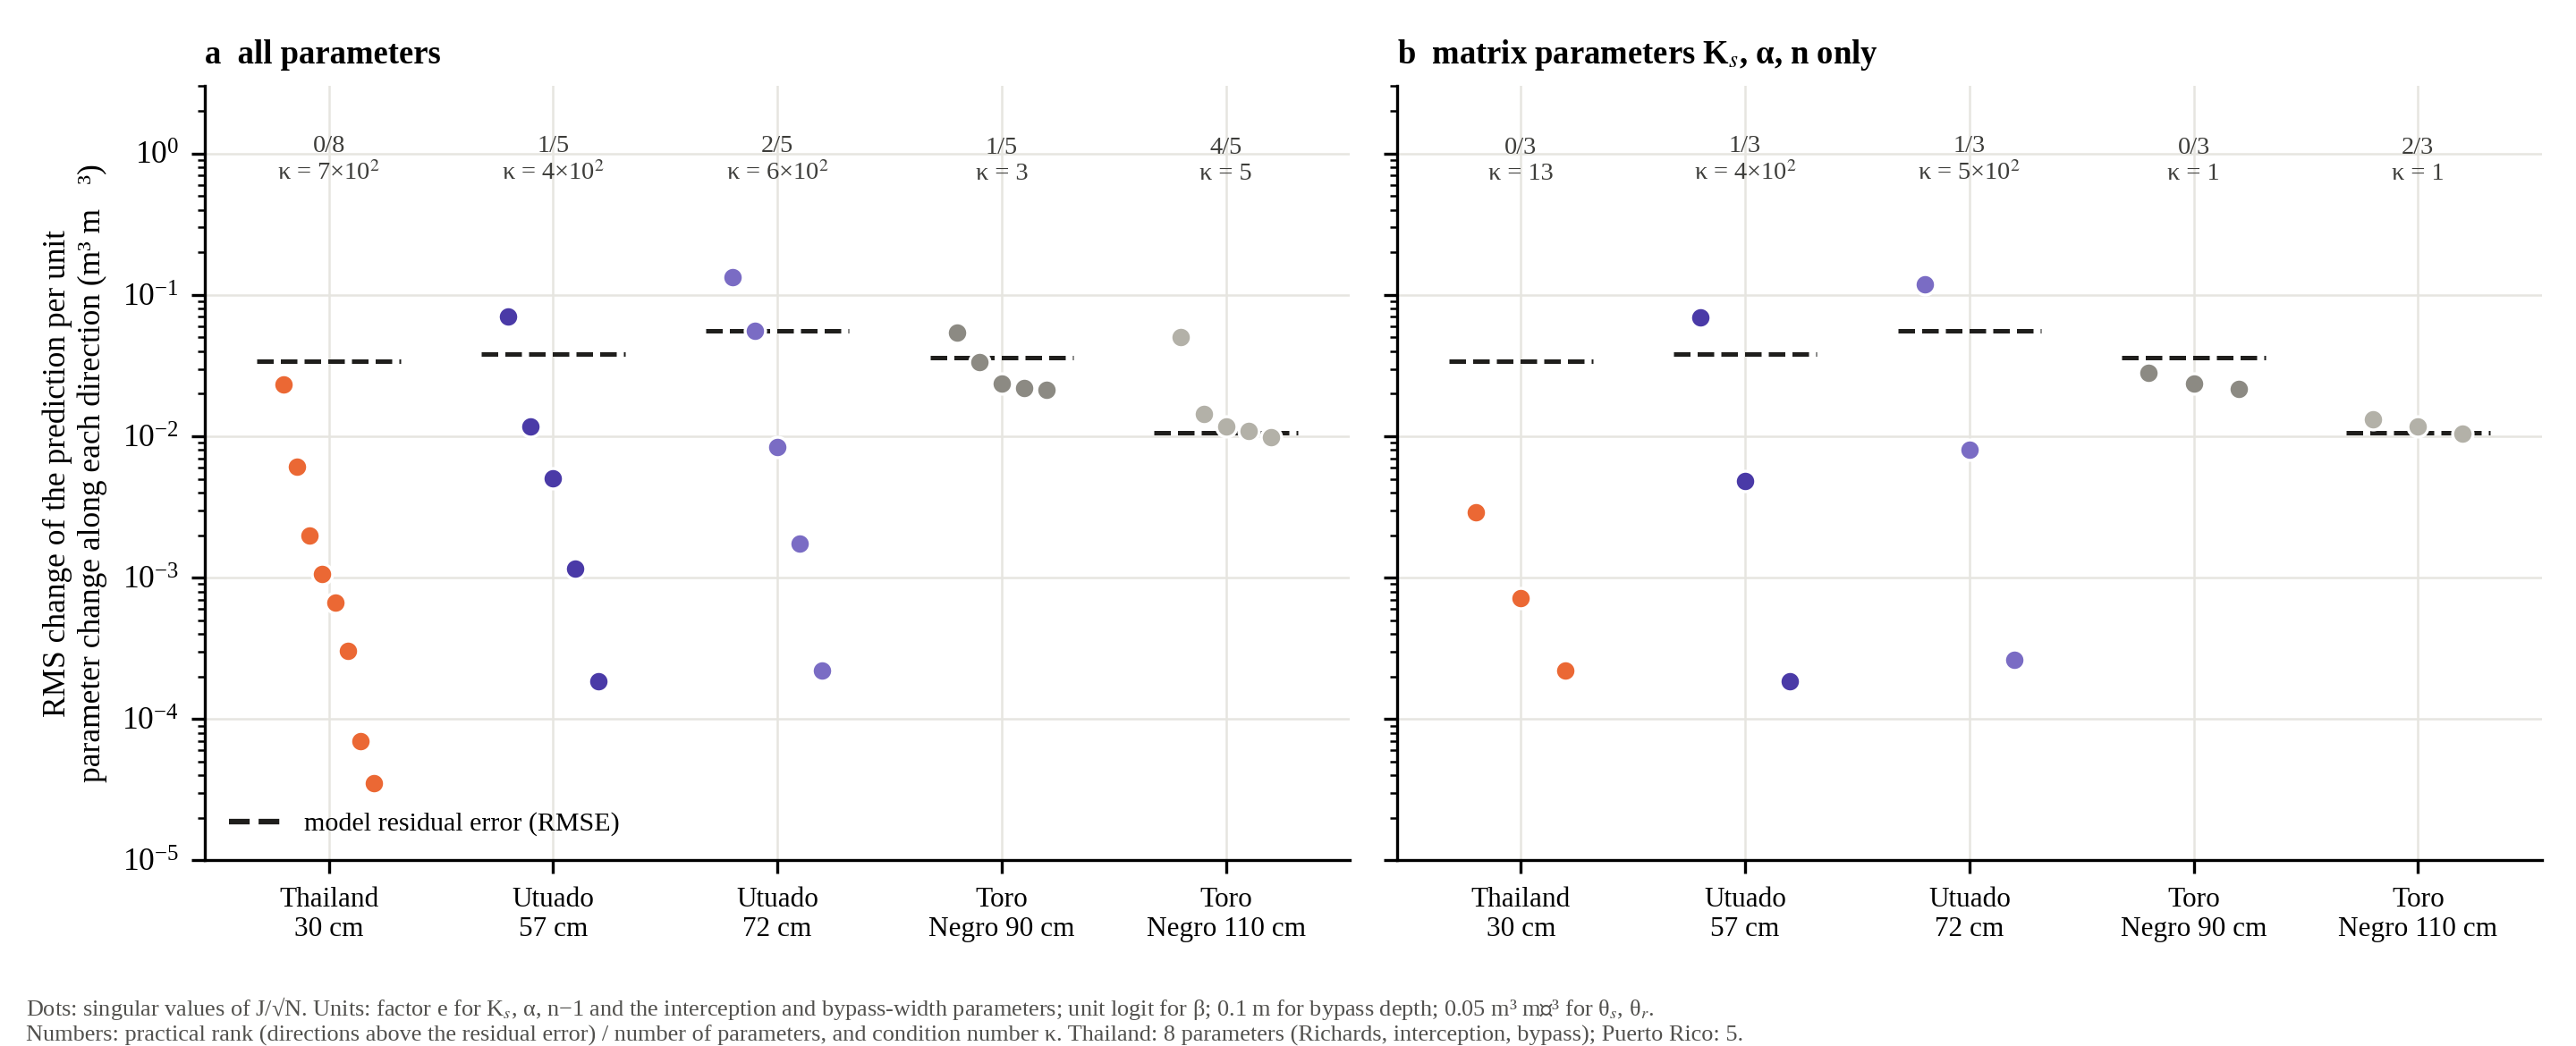

**FigS1**

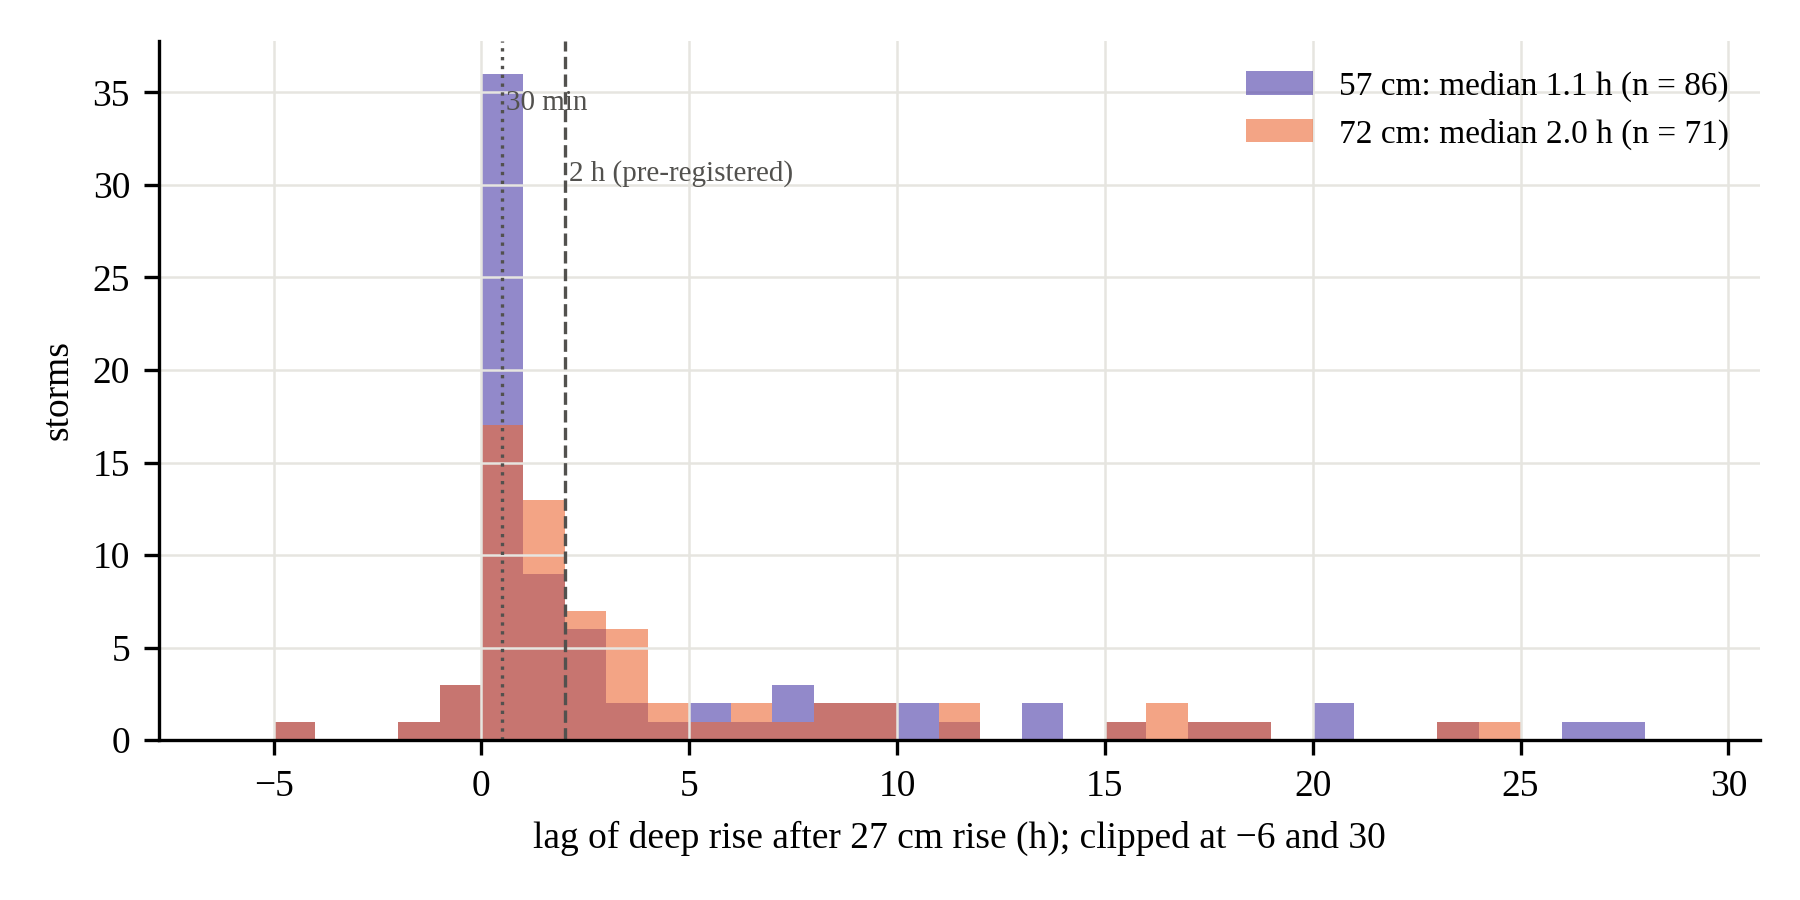

**FigS2**

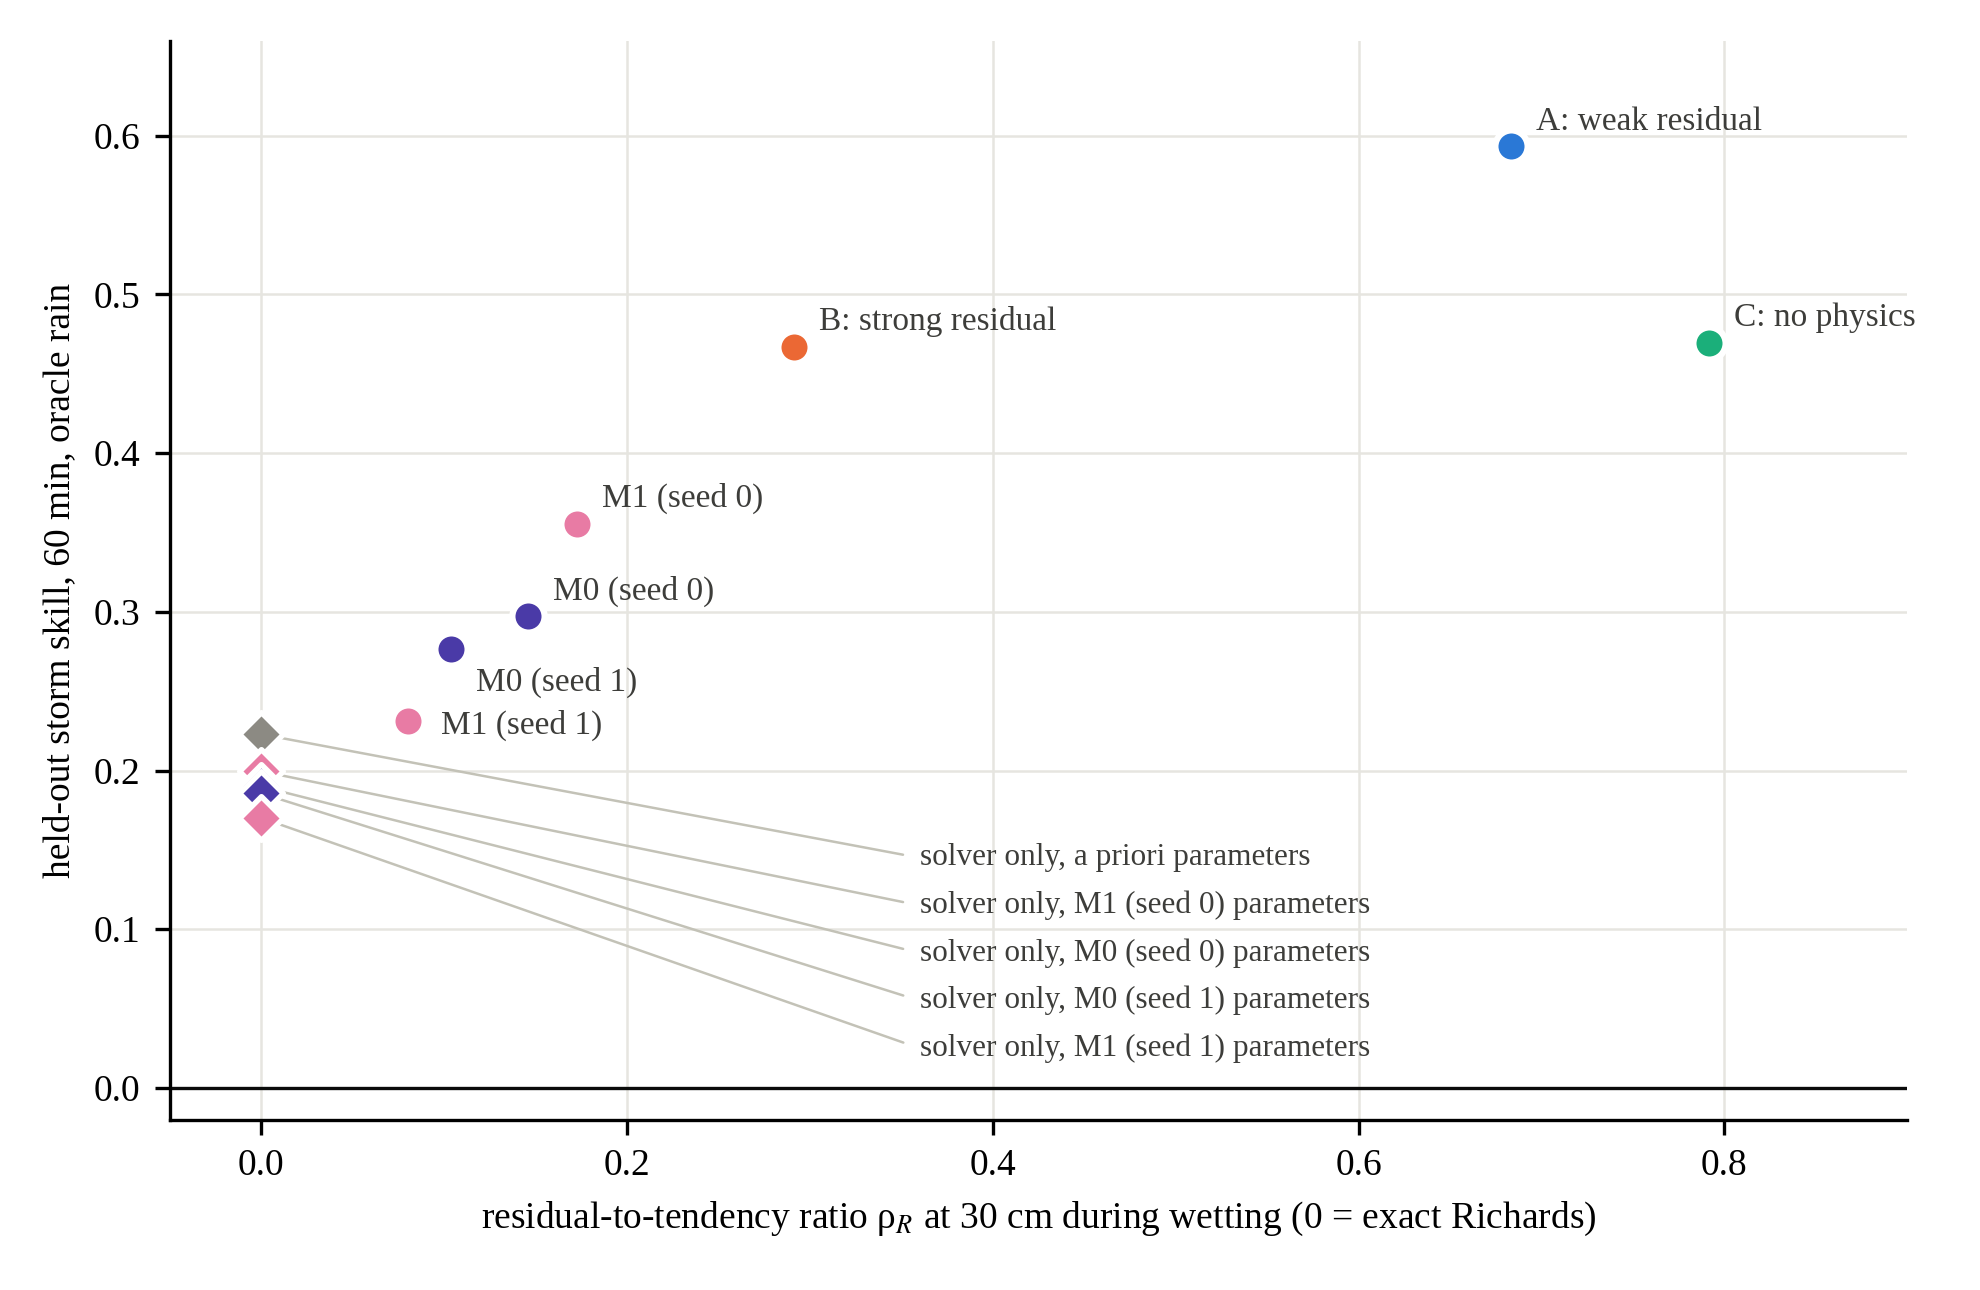

**FigS3**

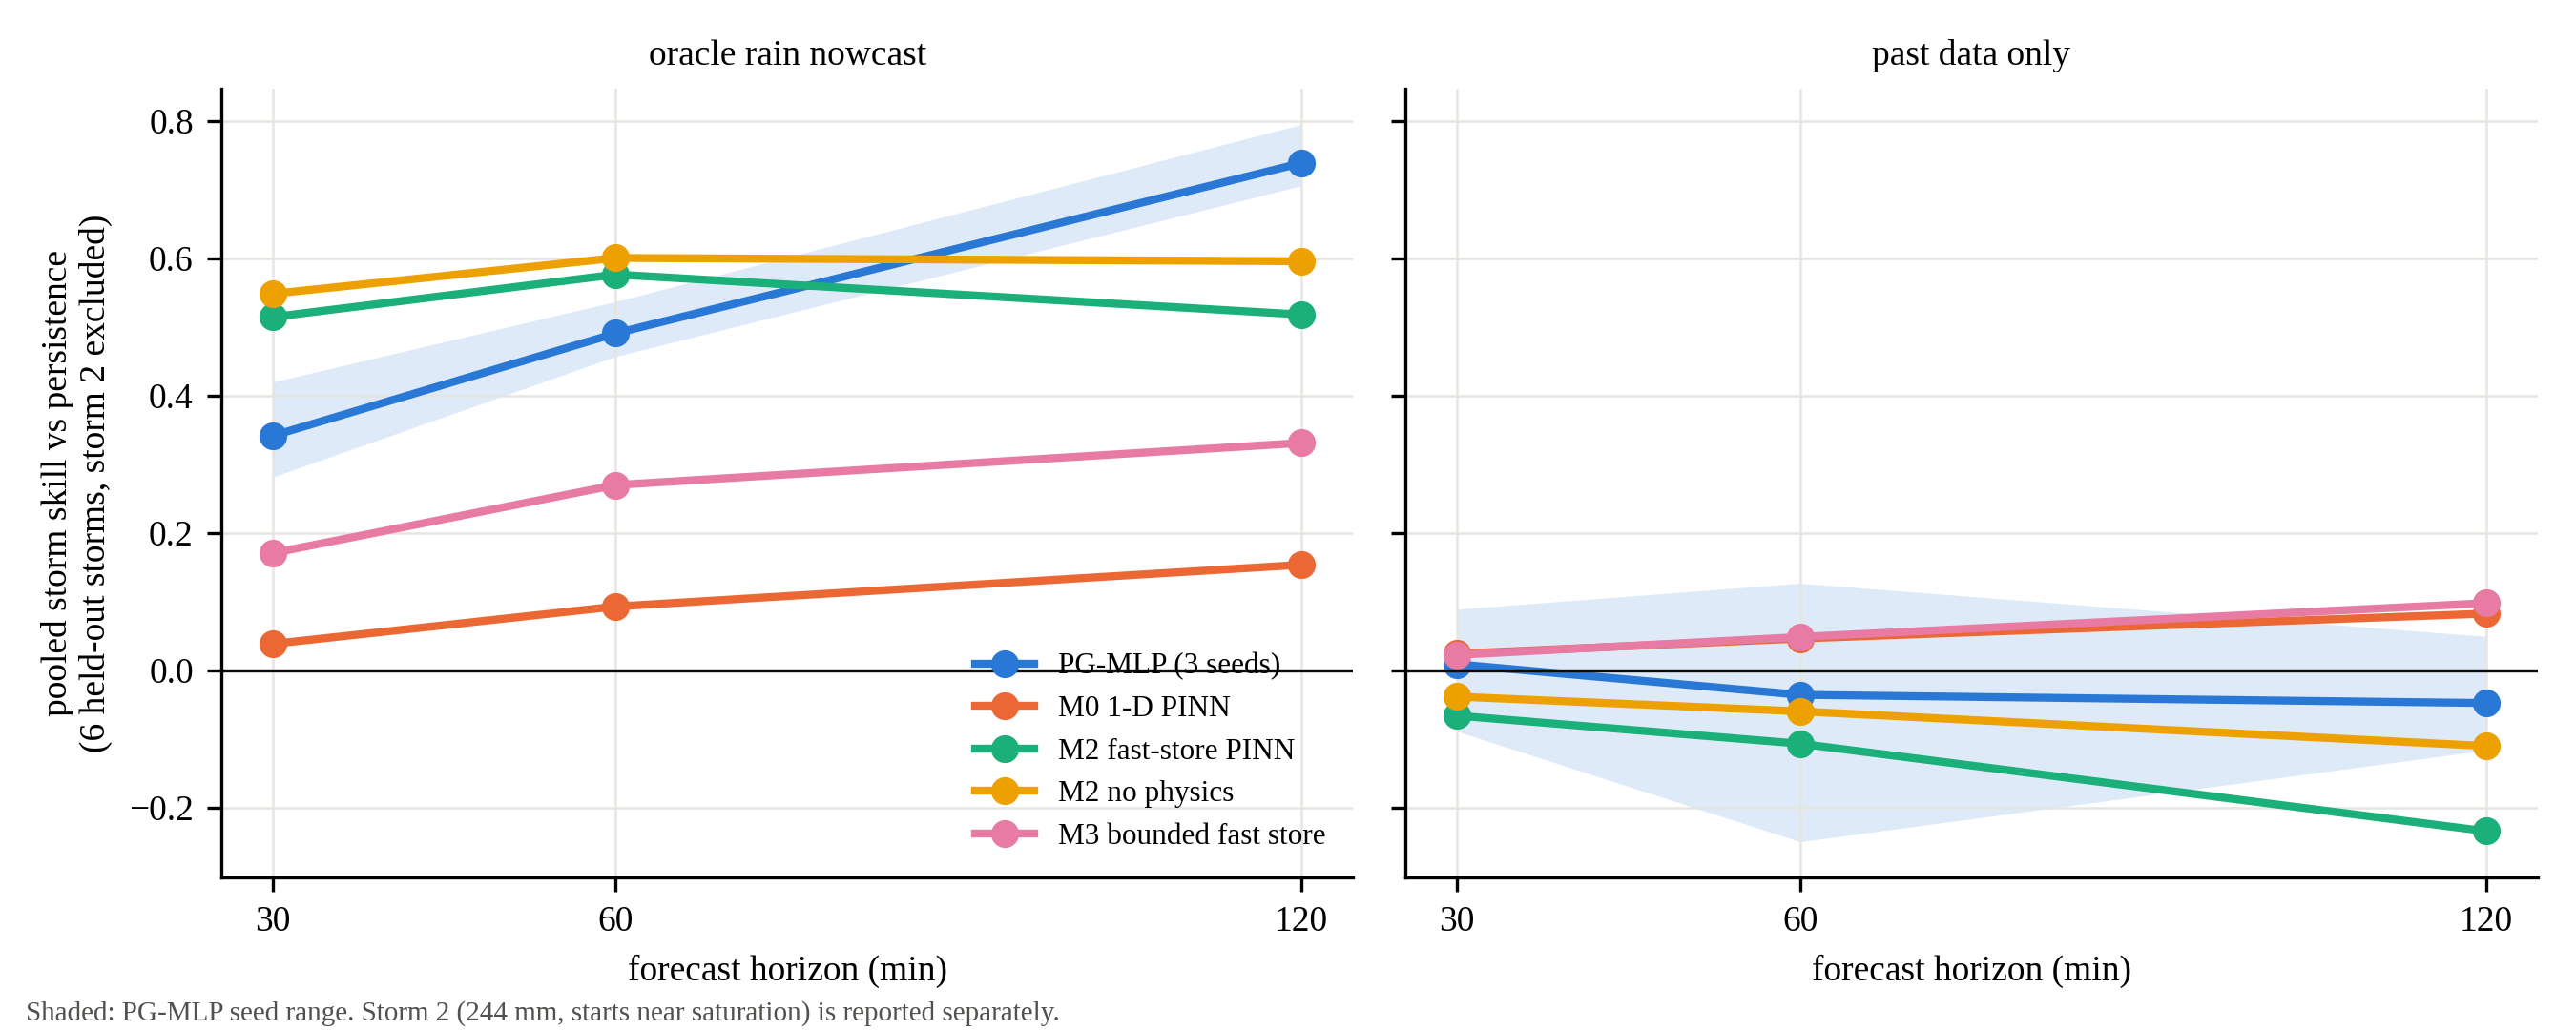

**FigS4**

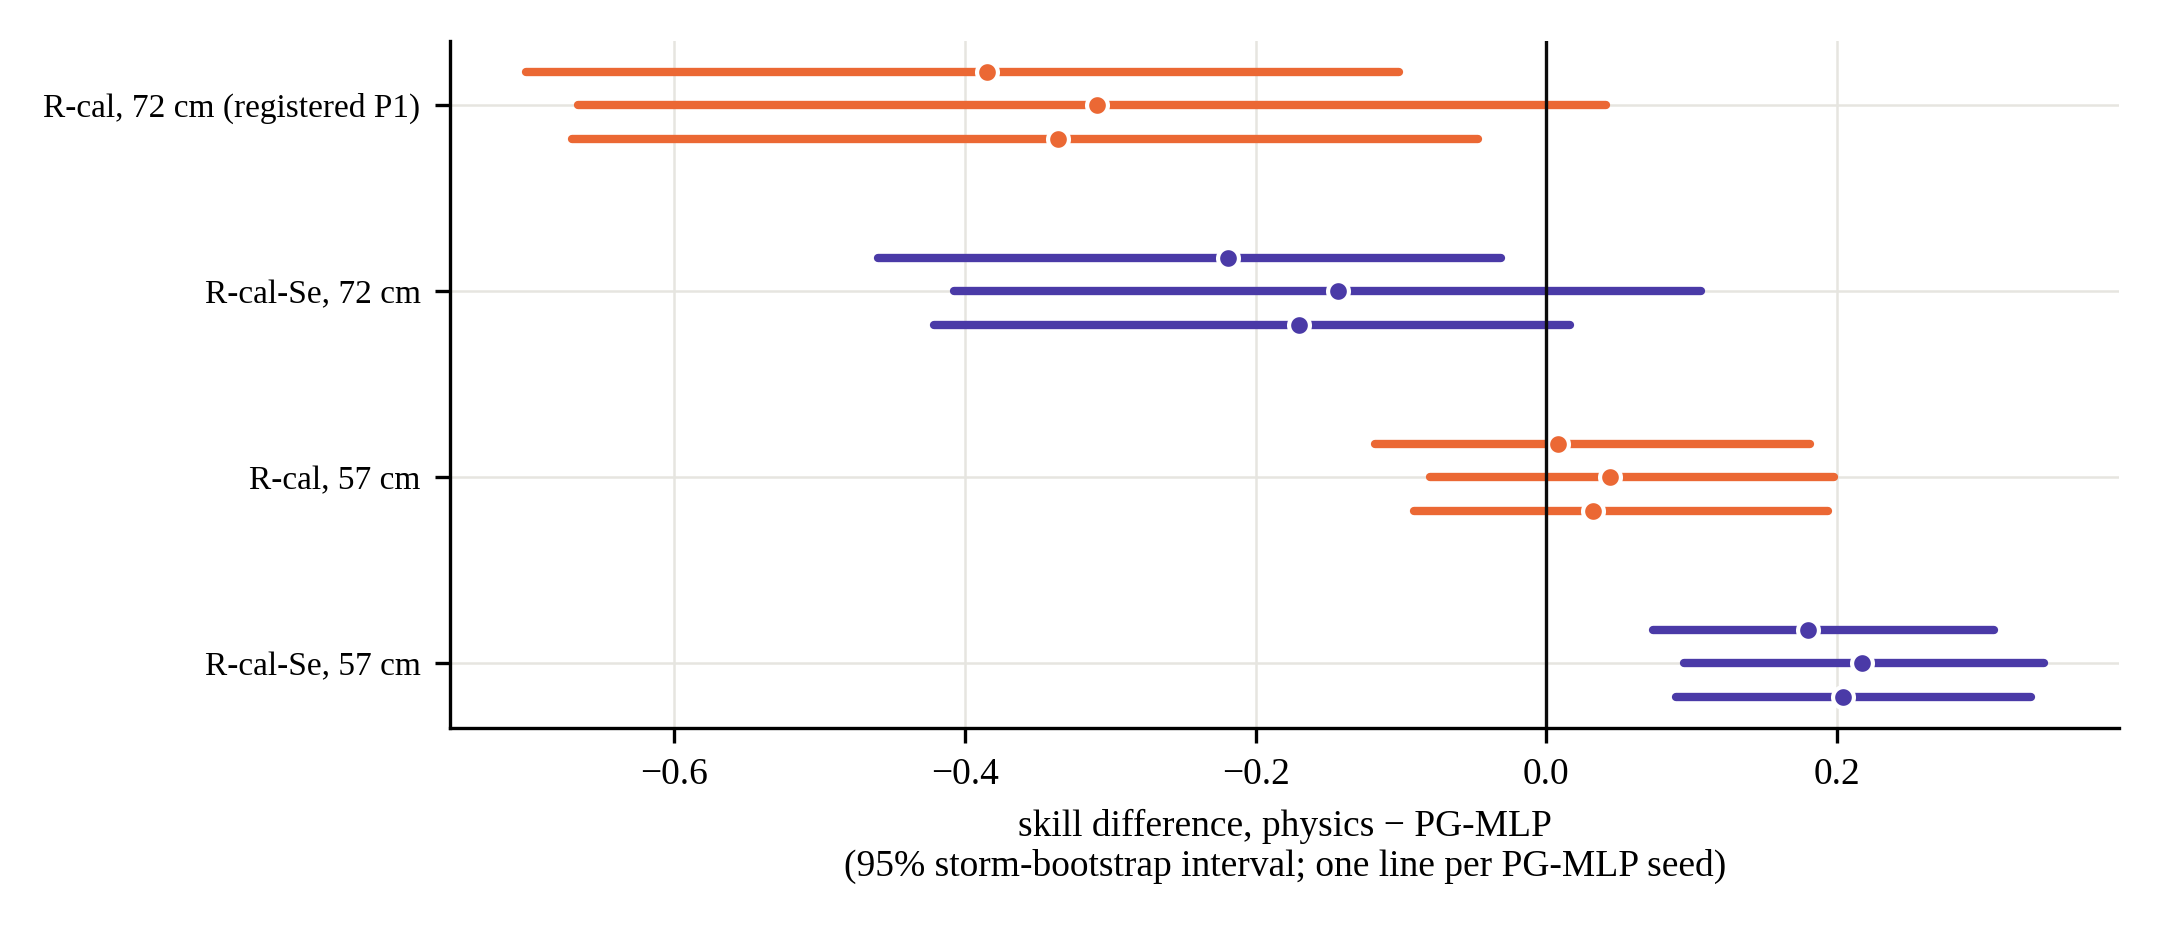

**FigS5**

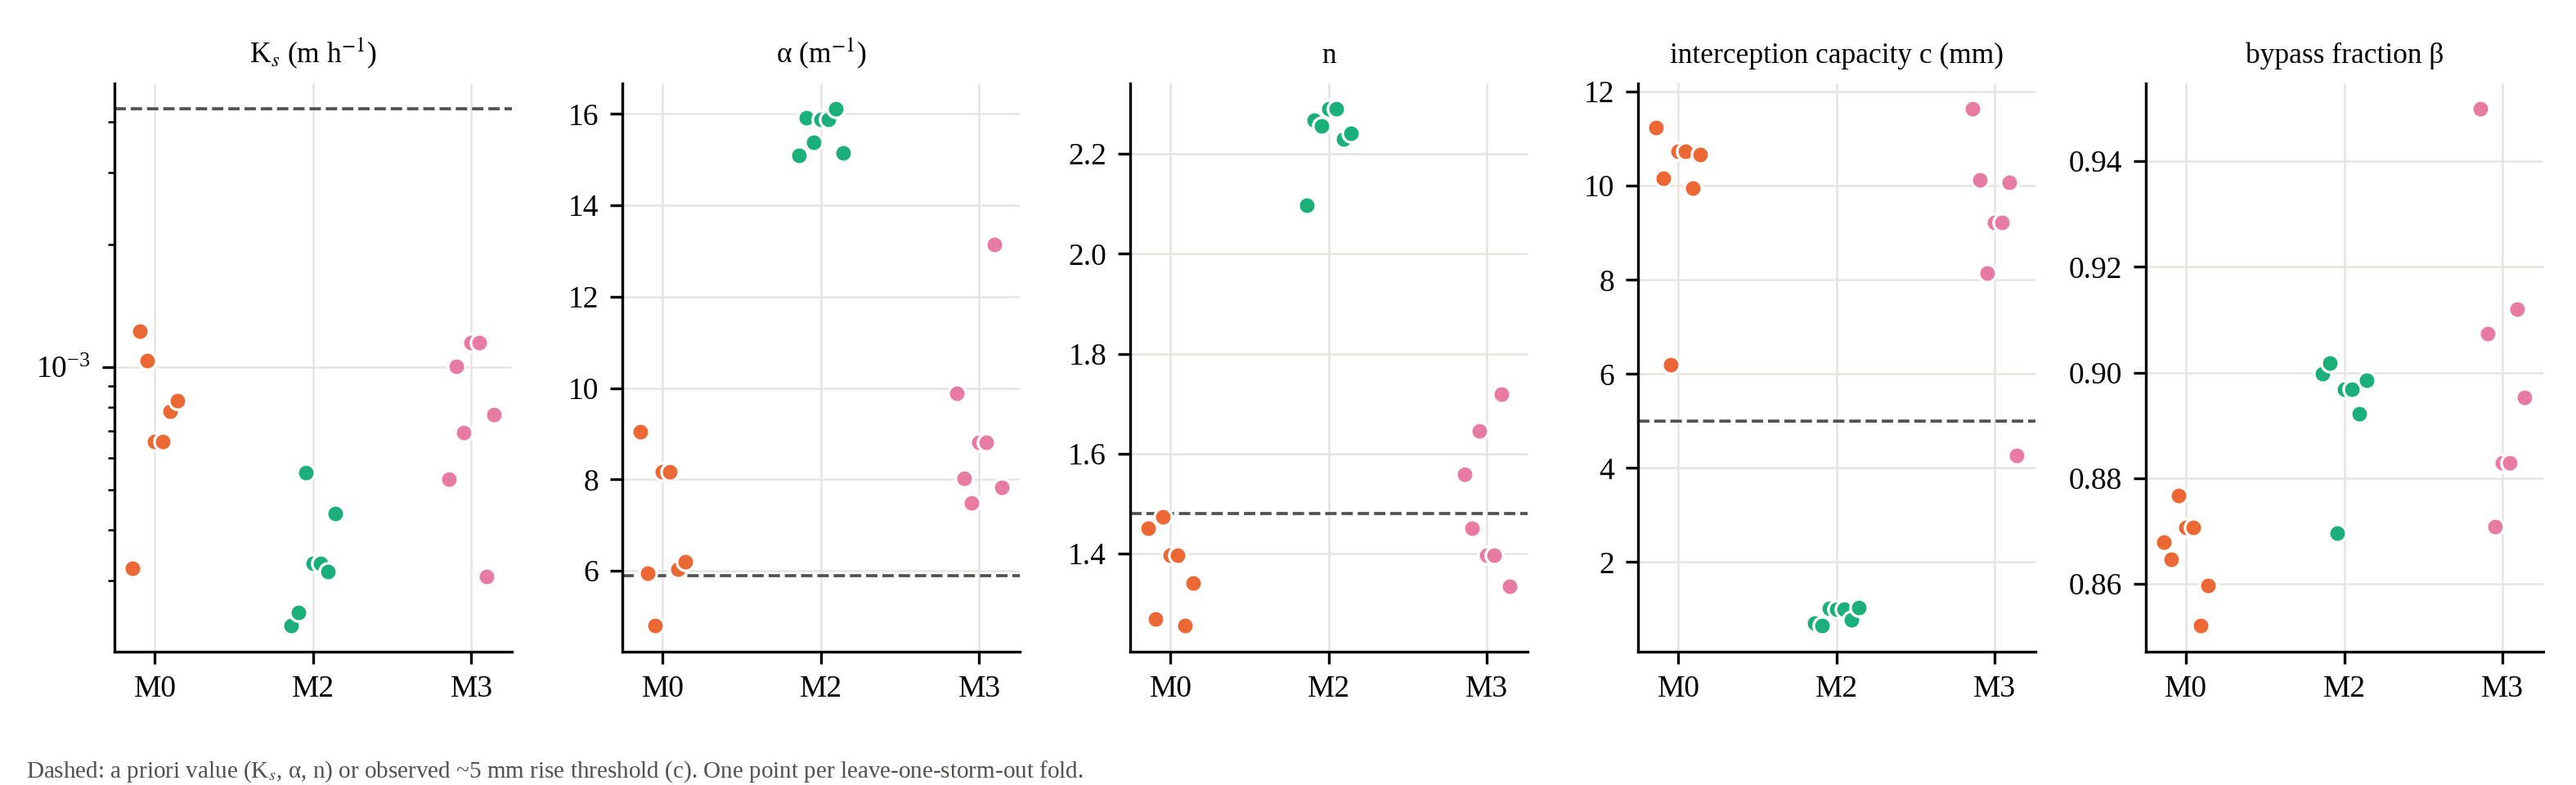

**FigS6**

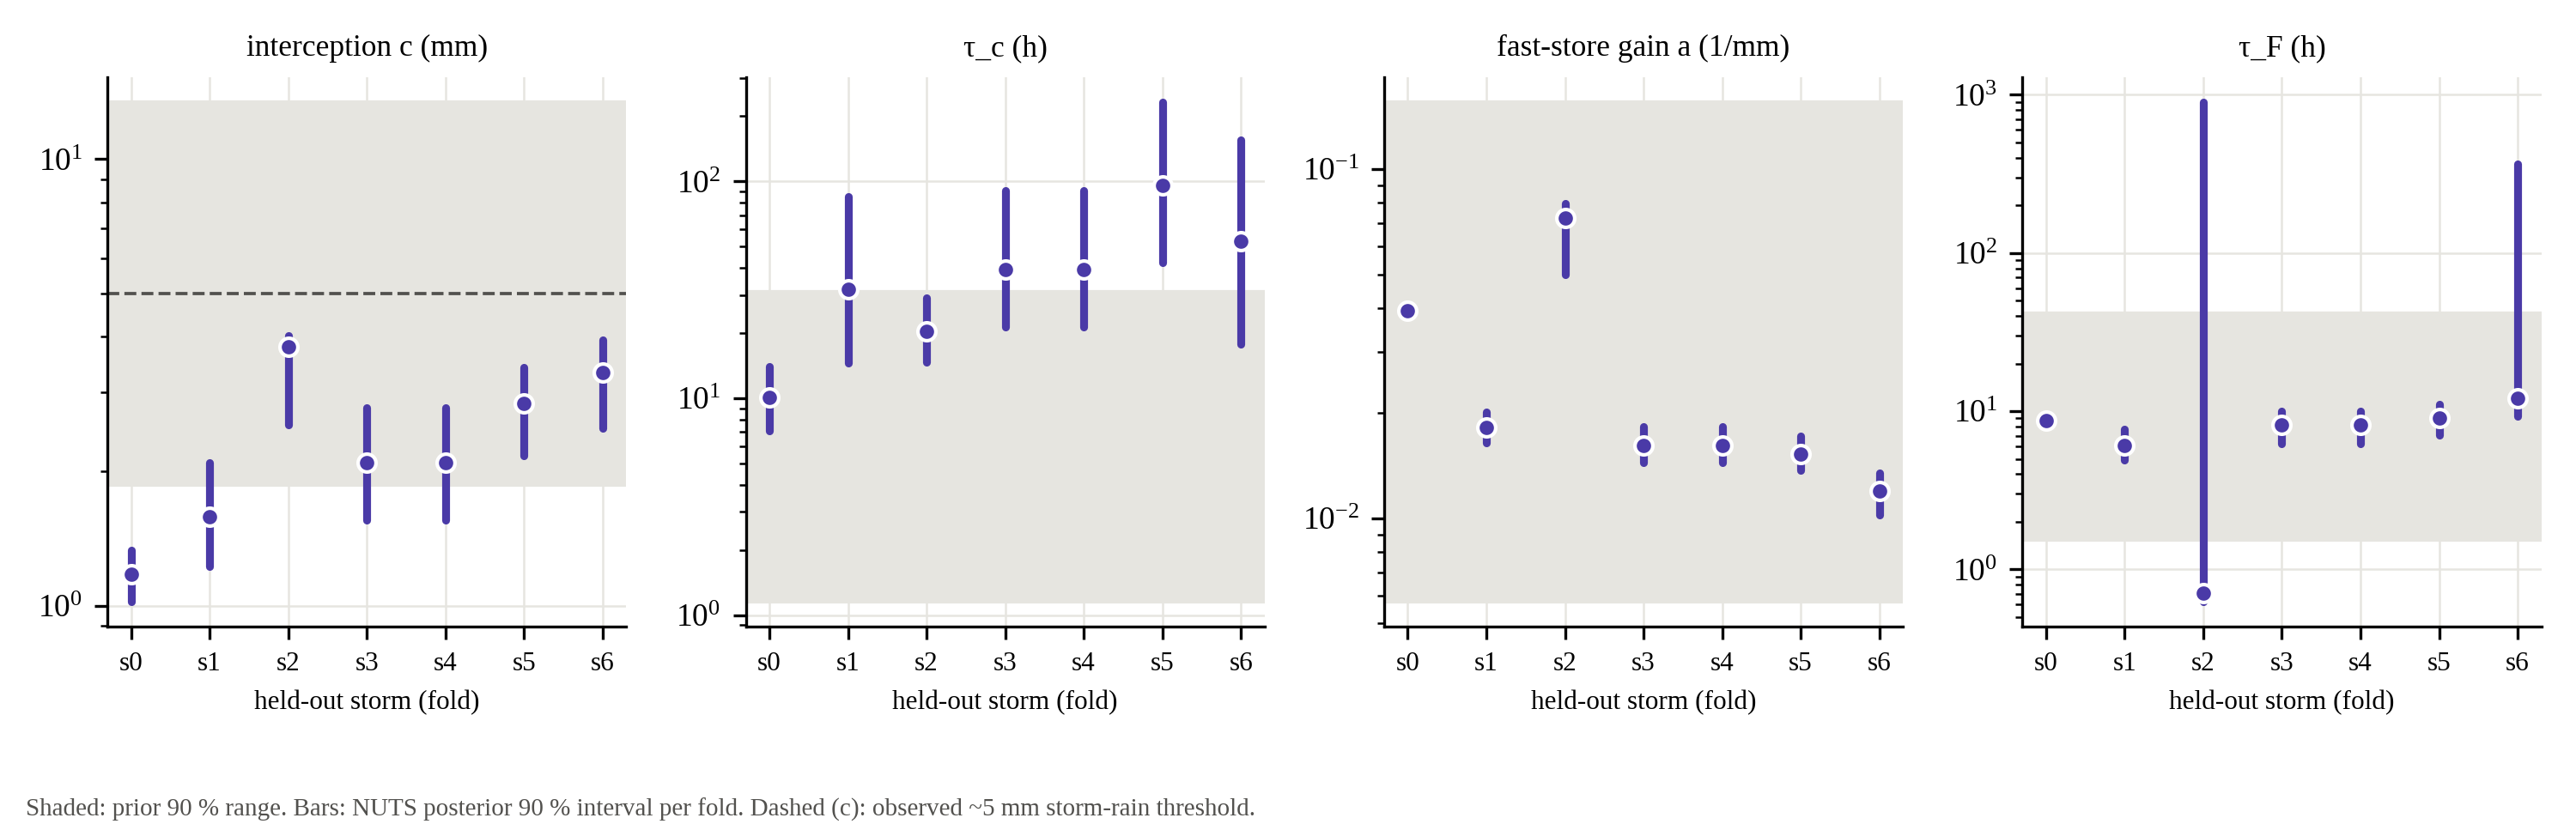

**FigS7**

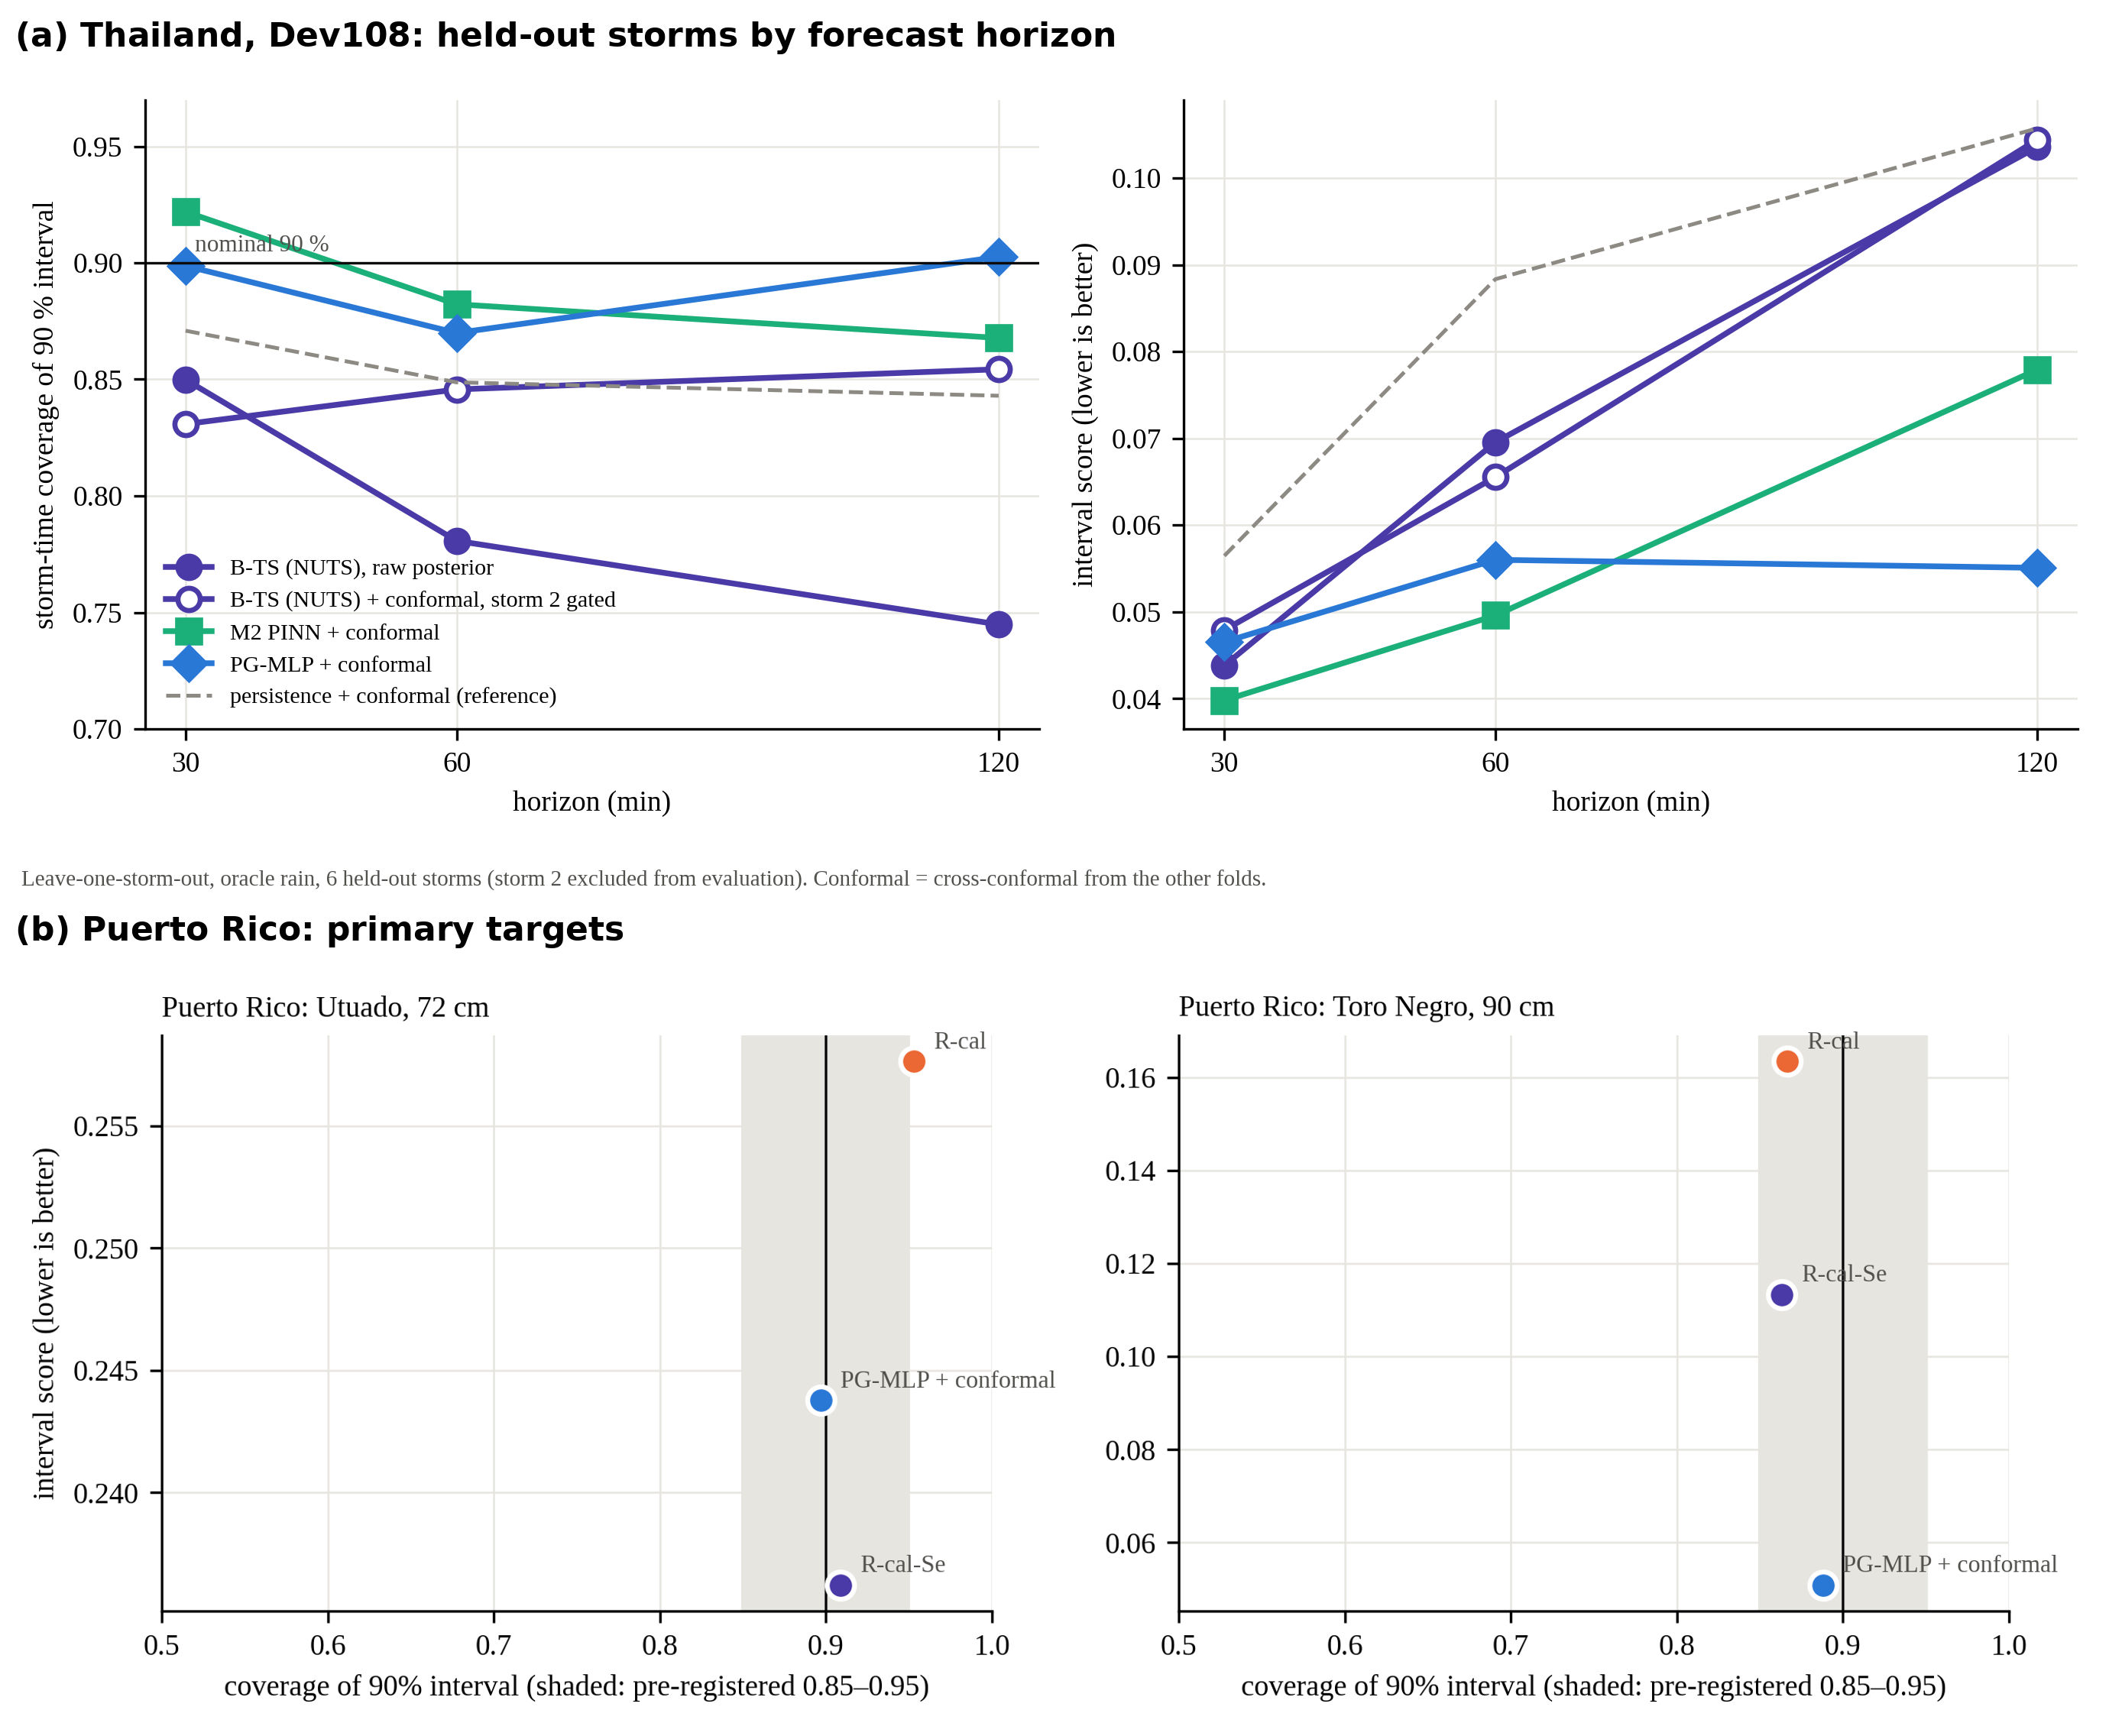

**FigS8**

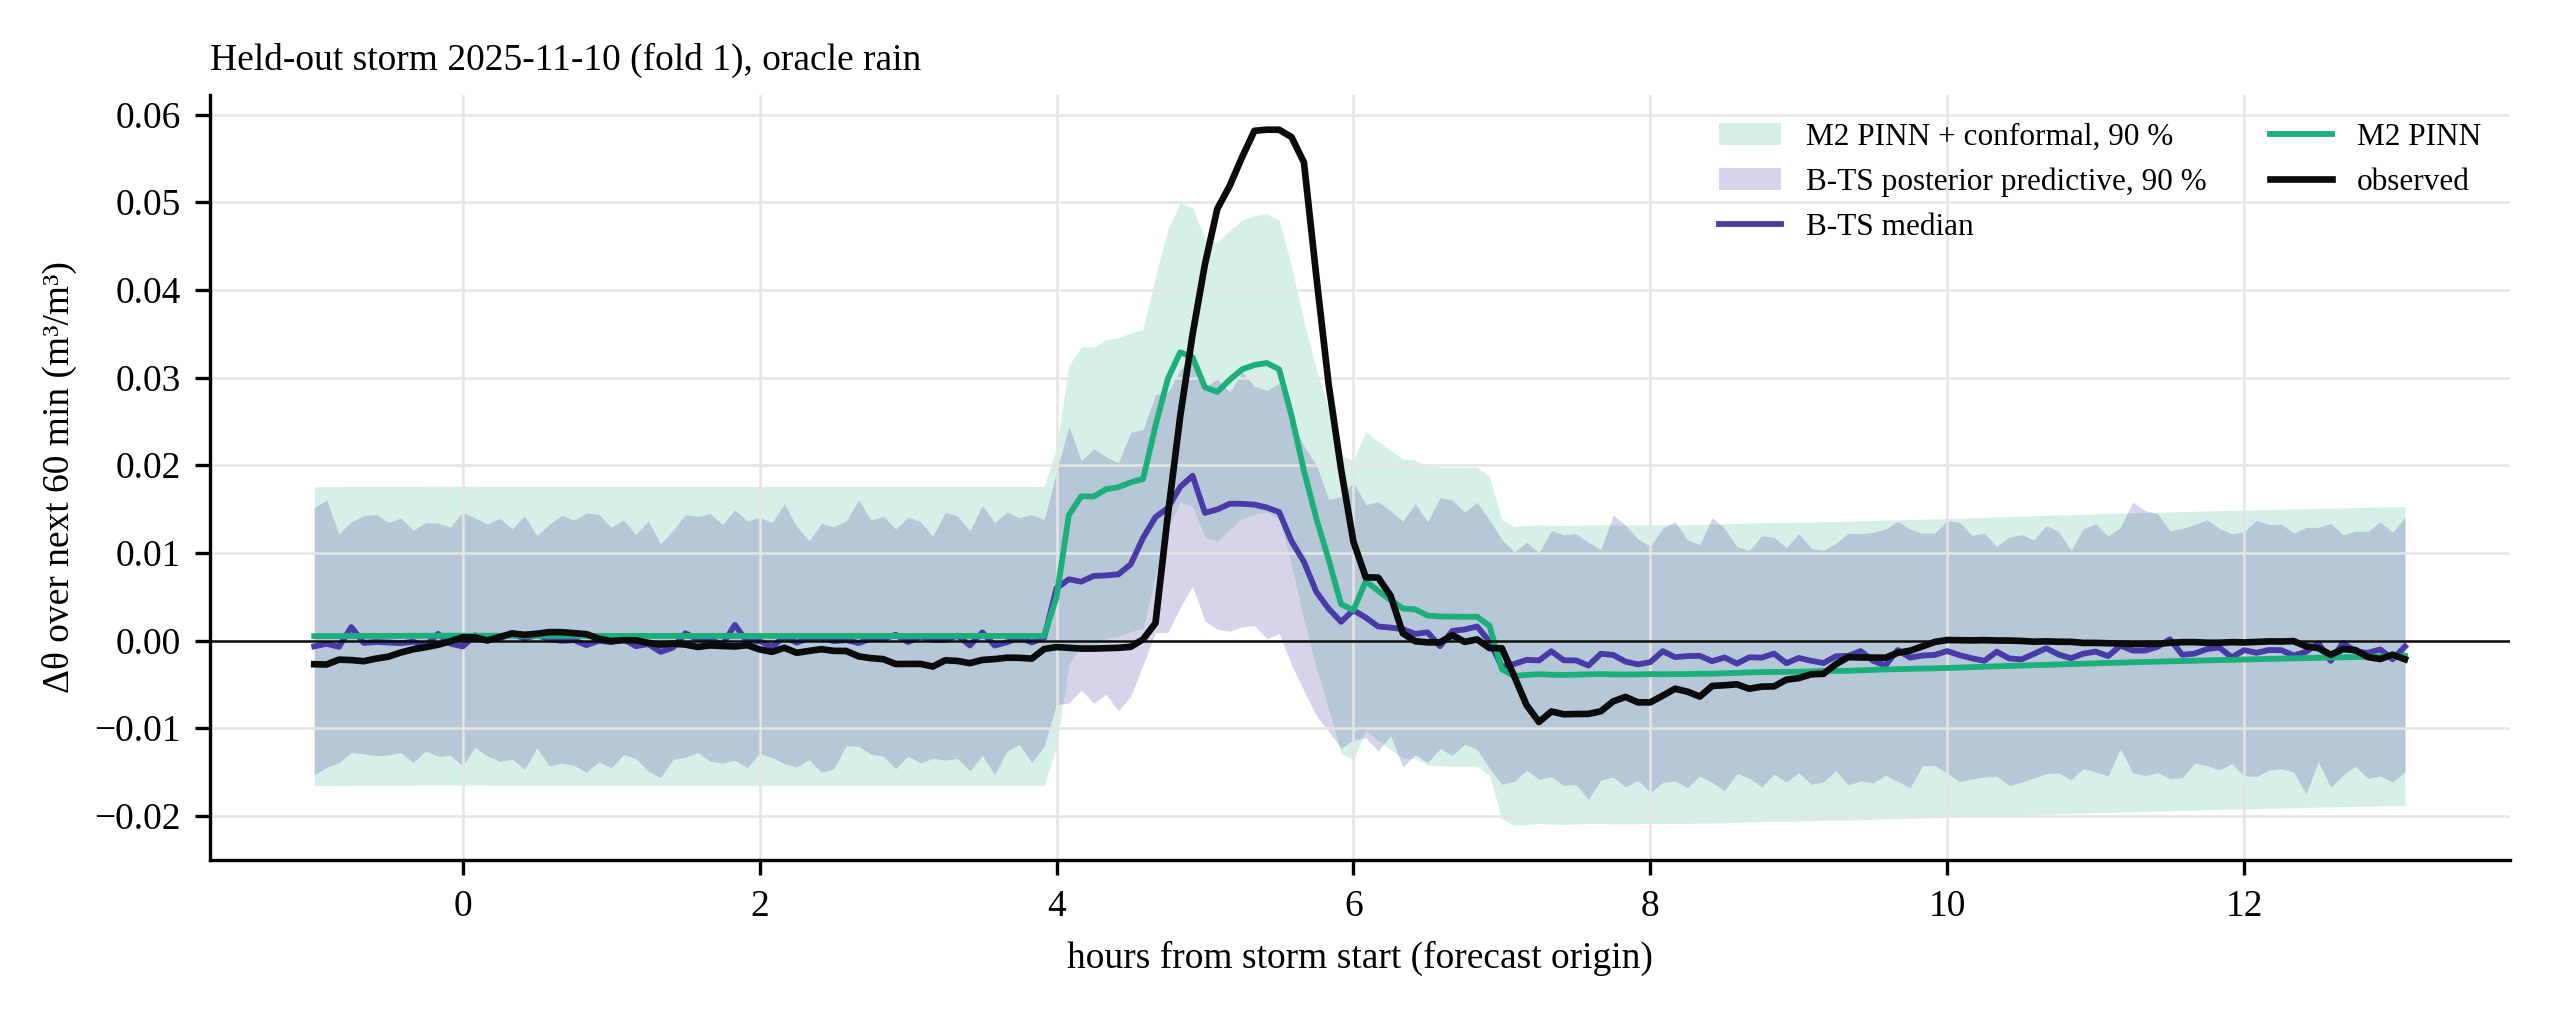

**FigS9**

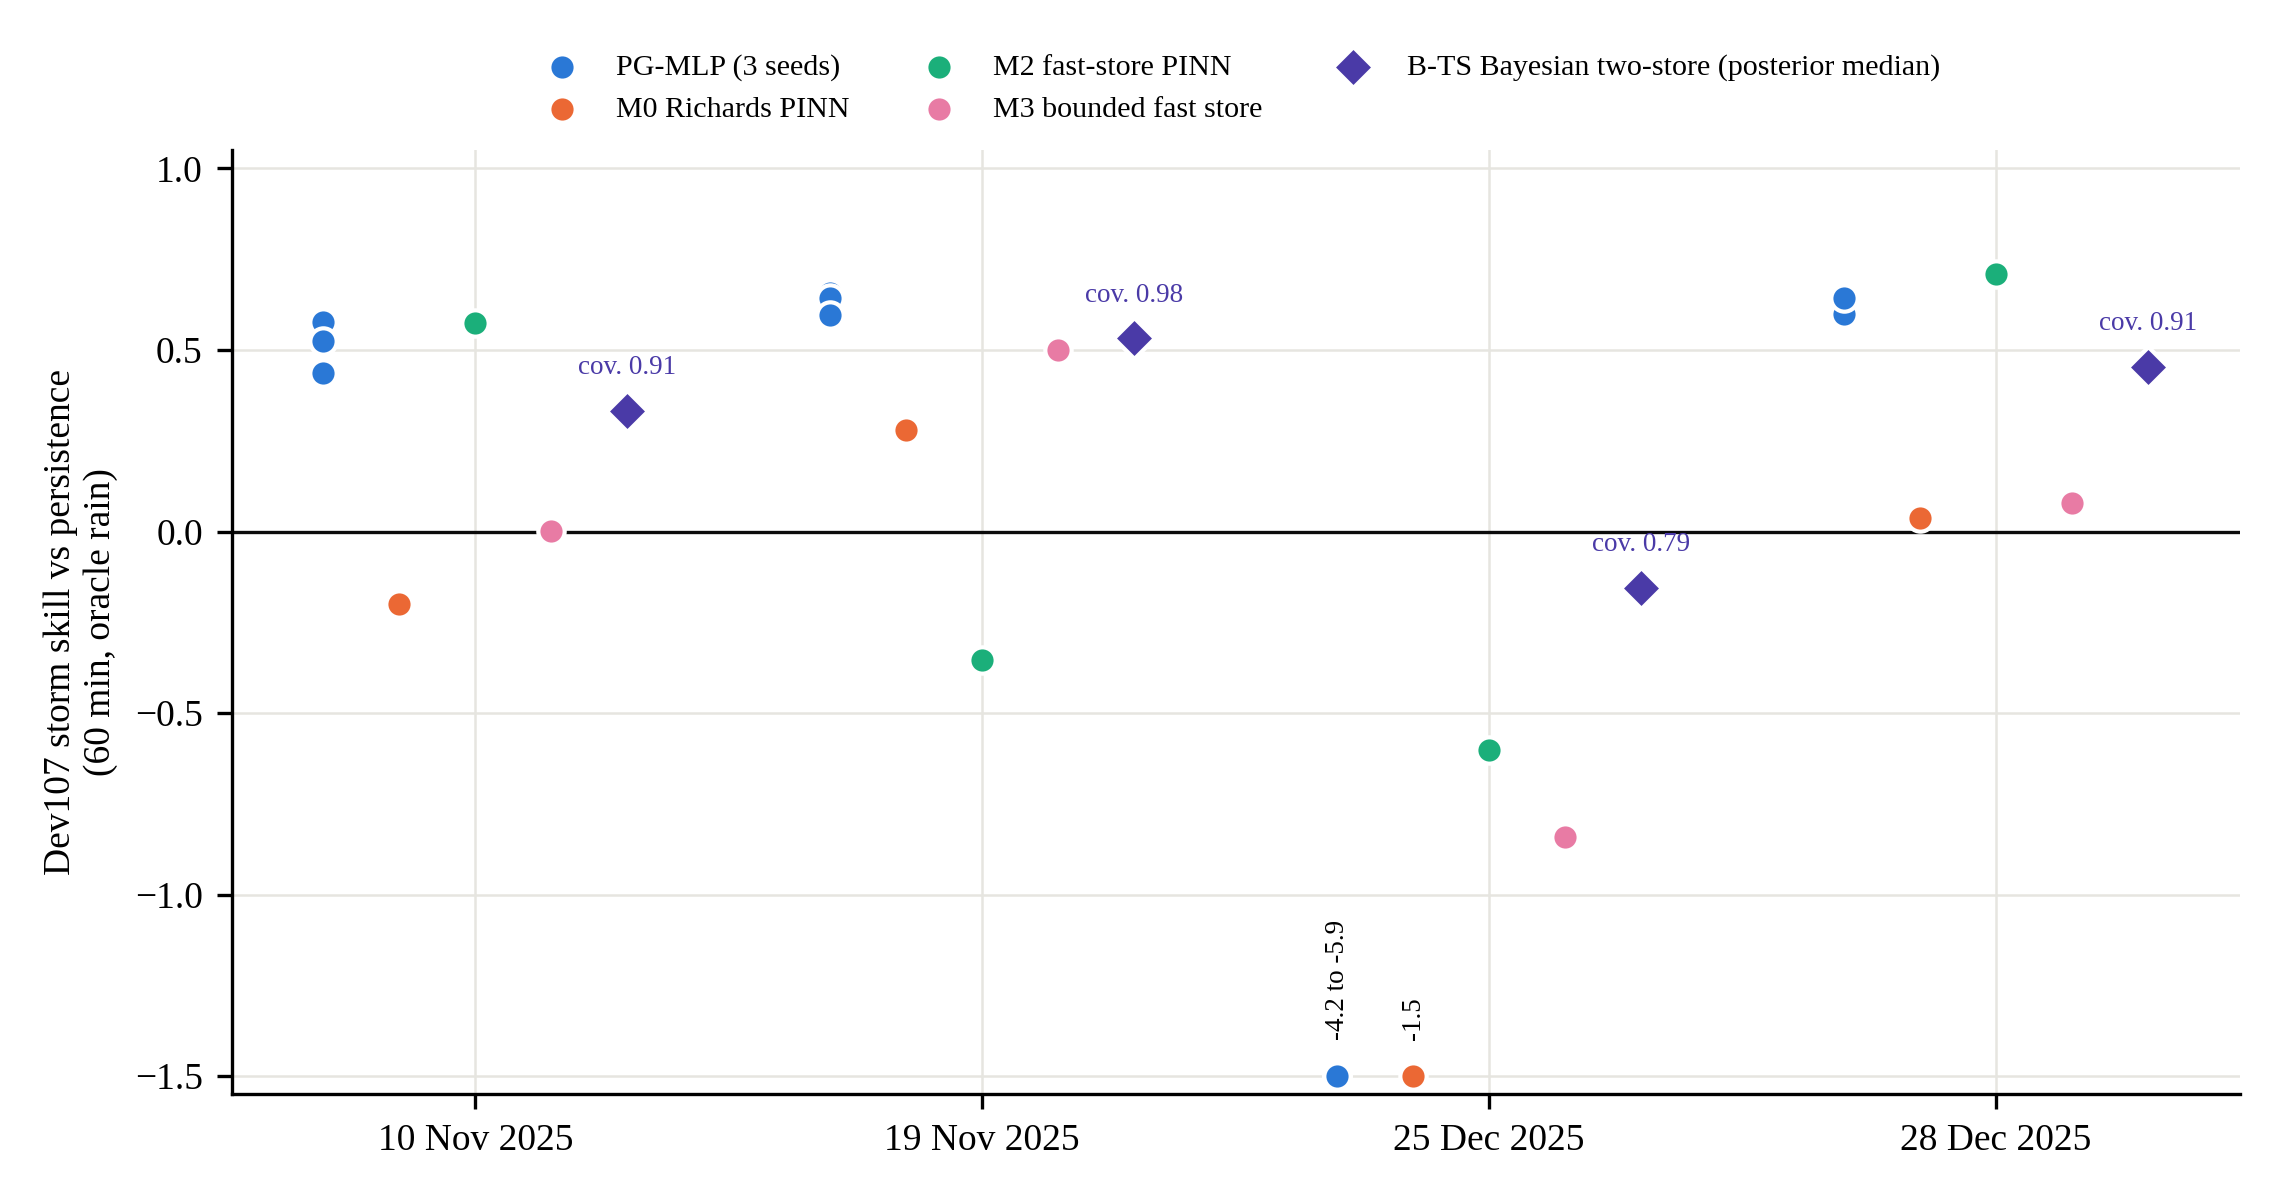

In [2]:
import os, sys, subprocess
subprocess.run(['apt-get','install','-qq','-y','fonts-liberation'], check=False)
cfg = os.path.abspath('mplcfg'); os.makedirs(cfg, exist_ok=True)
open(os.path.join(cfg, 'matplotlibrc'), 'w').write(
    "font.family : serif\n"
    "font.serif : Times New Roman, Liberation Serif, DejaVu Serif\n"
    "mathtext.fontset : stix\n")
os.environ['MPLCONFIGDIR'] = cfg
subprocess.run([sys.executable, 'figures/make_all_figures.py'], check=True)
from IPython.display import Image, display, Markdown
for f in sorted(os.listdir('figures/output')):
    display(Markdown(f'**{f[:-4]}**')); display(Image(os.path.join('figures/output', f), width=900))

## 2. Tables (tidy CSV versions of the manuscript tables)

In [3]:
subprocess.run([sys.executable, 'tables/make_tables.py'], check=True)
subprocess.run([sys.executable, 'figures/sensor_compare.py'], check=True, capture_output=True)
import pandas as pd; pd.set_option('display.width', 220); pd.set_option('display.max_columns', 30)
for f in sorted(os.listdir('tables')):
    if f.endswith('.csv'):
        display(Markdown(f'**{f}**')); display(pd.read_csv(os.path.join('tables', f)).head(30))

**Nowcast_degradation.csv**

,scenario,skill_60_min
0,oracle,0.537
1,"amount error, factor ~1.6 (sigma 0.5)",0.459
2,"amount error, factor ~2.7 (sigma 1.0)",0.262
3,timing error +30 min,0.332
4,timing error +60 min,0.117
5,missed 30% of rain,0.523
6,past-only model,0.015


**Table02_sensor_comparison.csv**

,Unnamed: 0,noise,resolution,p1,p99,range,missing,temp_sens,snr,median_run_min,tip
0,Dev108,0.0009,0.0000,0.3894,0.5306,0.1412,0.3889,0.0007,149.9389,1.0,NaN
1,Dev107,0.0006,0.0000,0.1923,0.4559,0.2637,0.8131,0.0005,461.0834,1.0,NaN
2,utuado 27cm,0.0004,0.0005,0.0931,0.3762,0.2831,0.0520,-0.0001,797.5967,NaN,NaN
3,utuado 57cm,0.0004,0.0005,0.0852,0.3431,0.2579,0.0520,-0.0001,688.4083,NaN,NaN
4,utuado 72cm,0.0003,0.0005,0.0526,0.3090,0.2564,0.0520,-0.0001,764.8145,NaN,NaN
5,utuado rain,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.2
6,toronegro 30cm,0.0004,0.0005,0.5125,0.5333,0.0207,0.0003,-0.0000,50.1980,NaN,NaN
7,toronegro 90cm,0.0003,0.0005,0.3648,0.4543,0.0894,0.6017,-0.0001,313.5283,NaN,NaN
8,toronegro 110cm,0.0005,0.0005,0.4251,0.4622,0.0371,0.0003,-0.0001,68.7293,NaN,NaN
9,toronegro rain,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.2


**Table05a_PR_lag_screening_P2.csv**

...

,configuration,sv_scaled,condition,resid_rmse,practical_rank,n_params,n_rows,n_dropped,col_rms,sv_over_resid,matrix_sv,matrix_rank,matrix_condition,matrix_corr,input_sensitivity_rms
0,Thailand 30 cm,"[0.02314625176164302, 0.006135825626992575, 0....",652.923525,0.033981,0,8,1559,0,"{""Ks_mph"": 0.0016522810205421858, ""alpha"": 0.0...","[0.6811564310611414, 0.18056733888213256, 0.05...","[0.0029165224044967134, 0.0007185440072073427,...",0,13.182635,"{""Ks_mph~alpha"": 0.5534859818720886, ""Ks_mph~n...",NaN
1,Utuado 72 cm,"[0.13260660770959187, 0.0557940166356527, 0.00...",602.630246,0.055503,2,5,16245,0,"{""log Ks"": 0.044672269151731385, ""log alpha"": ...","[2.3891796681562343, 1.005243497689067, 0.1512...","[0.11888659676931299, 0.008066289353084044, 0....",1,451.848080,"{""log Ks~log alpha"": -0.999933282287882, ""log ...",0.874725
2,Utuado 57 cm,"[0.07083381758519522, 0.011730661380093094, 0....",383.155012,0.038006,1,5,16245,0,"{""log Ks"": 0.026912384847289916, ""log alpha"": ...","[1.8637357473887566, 0.3086499316275976, 0.133...","[0.06889705458040513, 0.00481714939274928, 0.0...",1,371.913898,"{""log Ks~log alpha"": -0.9999173243866695, ""log...",0.888915
3,Toro Negro 90 cm,"[0.05436851584586352, 0.033290030435064774, 0....",2.564369,0.036189,1,5,16798,0,"{""log Ks"": 0.023424884708529433, ""log alpha"": ...","[1.5023417968093555, 0.9198890821563313, 0.652...","[0.027981353084904886, 0.023767206138406317, 0...",0,1.291365,"{""log Ks~log alpha"": 0.1036987755596868, ""log ...",0.000000
4,Toro Negro 110 cm,"[0.050148861783200195, 0.014490264178923403, 0...",5.058639,0.010554,4,5,16798,0,"{""log Ks"": 0.011394969495672131, ""log alpha"": ...","[4.751458215079113, 1.3729102181672412, 1.1169...","[0.013211323444684665, 0.011787480228237394, 0...",2,1.270021,"{""log Ks~log alpha"": -0.003449767887493734, ""l...",0.000000


**TableS9a_Thai_band_calibration.csv**

,model,h,coverage,mean width,interval score,skill
0,B-TS vi (raw),30,0.855,0.018,0.044,0.392
1,B-TS vi (raw),60,0.785,0.027,0.069,0.379
2,B-TS vi (raw),120,0.745,0.036,0.105,0.242
3,B-TS vi + conformal,30,1.000,0.110,0.110,0.392
4,B-TS vi + conformal,60,1.000,0.114,0.114,0.379
5,B-TS vi + conformal,120,1.000,0.128,0.128,0.242
6,B-TS nuts (raw),30,0.850,0.017,0.044,0.396
7,B-TS nuts (raw),60,0.781,0.027,0.070,0.382
8,B-TS nuts (raw),120,0.745,0.037,0.104,0.252
9,B-TS nuts + conformal,30,0.859,0.022,0.045,0.396


**TableS9b_PR_band_calibration_P4.csv**

,site,model,coverage,width,interval_score,skill,n
0,utuado,R-cal Laplace (registered),0.953,0.204,0.258,-0.146,36095
1,utuado,R-cal-Se Laplace (exploratory),0.909,0.153,0.236,0.165,36095
2,utuado,PG-MLP s0 + cross-conformal,0.897,0.128,0.244,0.389,36019
3,toronegro,R-cal Laplace (registered),0.866,0.110,0.163,-1.194,21459
4,toronegro,R-cal-Se Laplace (exploratory),0.863,0.072,0.113,-0.253,21459
5,toronegro,PG-MLP s0 + cross-conformal,0.888,0.038,0.051,0.730,21459


## 3. Integrity checks

In [4]:
import hashlib, json
h = hashlib.sha256(open('puerto_rico/PREREGISTRATION.md', 'rb').read()).hexdigest()
print('Puerto Rico pre-registration SHA-256 matches the frozen value:', h == open('puerto_rico/PREREG_SHA256.txt').read().split()[0])
print(open('data/CHECKSUMS.sha256').read())
r = subprocess.run(['sha256sum', '-c', 'data/CHECKSUMS.sha256'], capture_output=True, text=True); print(r.stdout or r.stderr)

Puerto Rico pre-registration SHA-256 matches the frozen value: True
9a0e764a399ce8cdd95235e24eab3e8cb800fdf34aab10be2f6bd903f72e6198  data/thailand/107_pinn.csv
4557b42317e175c5d1aaafb2ae554e0f0d3600b4cd0a84c0a57aa06d221021fc  data/thailand/pinn_108_new.csv
feb1717b715d68f34796c55fd5f6c4ea41cfbd9bc87691ce3c703906c0080cb8  data/puerto_rico/toroNegro_15min.csv
8e3e12b5a218692e5761ef7a01329aa7ac8017cf5cfa2234eda373a5061e72e8  data/puerto_rico/utuado_15min.csv
b9ff2a8c80175a2410bd9844caf7c1d8778d020b0b124d466c6804981305fe0f  data/puerto_rico/PuertoRico_TestingData.xlsx

data/thailand/107_pinn.csv: OK
data/thailand/pinn_108_new.csv: OK
data/puerto_rico/toroNegro_15min.csv: OK
data/puerto_rico/utuado_15min.csv: OK
data/puerto_rico/PuertoRico_TestingData.xlsx: OK

